# b2metric Case Study
Bora Boyacıoğlu, boraboyacioglu@icloud.com

In [1]:
# I used a virtual environment for this notebook.
#% python3 -m venv .venv
#% source .venv/bin/activate

# Python 3.13.2

%pip install -q --upgrade pip
%pip install -q jupyter ipykernel pandas matplotlib scikit-learn catboost lofo-importance optuna shap

# My own library just for coloured outputs.
%pip install -q AnsiLib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Pull the Kaggle dataset.
# URL: https://www.kaggle.com/competitions/home-credit-default-risk/data?select=application_train.csv

In [3]:
RETRAIN = True  # Set to False to prevent running codes which take too much time.

In [4]:
RANDOM_STATE = 17

Import necessary libraries.

In [5]:
import os
import pickle
import warnings

from contextlib import contextmanager

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import RidgeClassifier

from catboost import CatBoostClassifier
from lofo import LOFOImportance, Dataset, plot_importance
import optuna
import shap

import AnsiLib as al

/Users/wndpzr/GitHub/b2metric-case-study/.venv/lib/python3.13/site-packages/lofo/lofo_importance.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [6]:
# Context manager to suppress runtime warnings.
# Used in RidgeClassifier here.
@contextmanager
def suppress_warnings(categories):
    original_filters = warnings.filters[:]
    original_settings = np.seterr()

    try:
        for category in categories:
            warnings.filterwarnings('ignore', category=category)
        np.seterr(divide='ignore', over='ignore', invalid='ignore')
        yield
    finally:
        warnings.filters = original_filters
        warnings._filters_mutated()  # type: ignore
        np.seterr(**original_settings)

## 1. Data Loading and Preprocessing

In [7]:
# Load the main dataset.
df = pd.read_csv('data/application_train.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.

In [8]:
# Split the dataset into features and target variable.
X = df.drop(columns=['TARGET'])
y = df['TARGET']
del df

### Outlier Handling

As I reviewed the leaderboard of the [Kaggle Competition](https://www.kaggle.com/competitions/home-credit-default-risk/code), I inspected there are some outlier values in some columns.

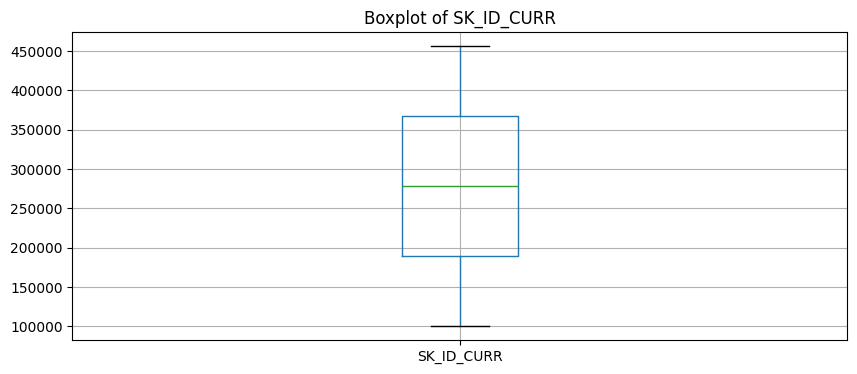

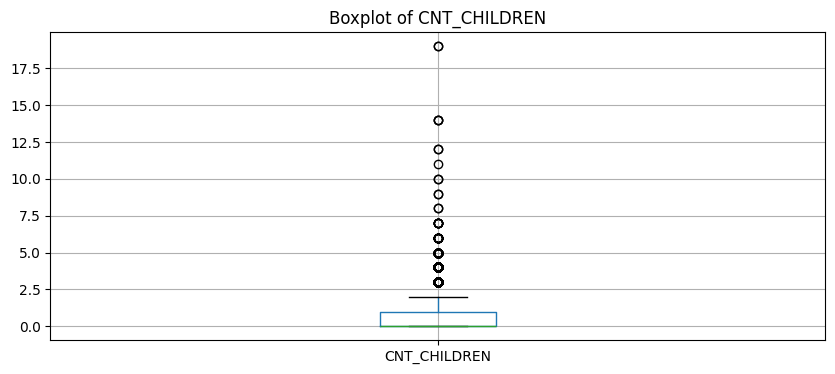

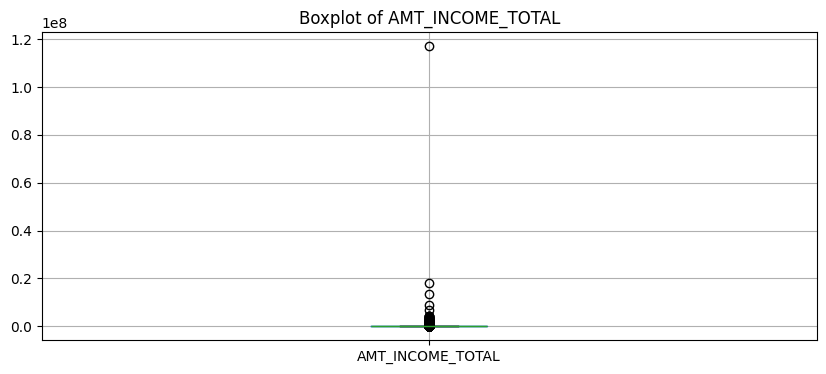

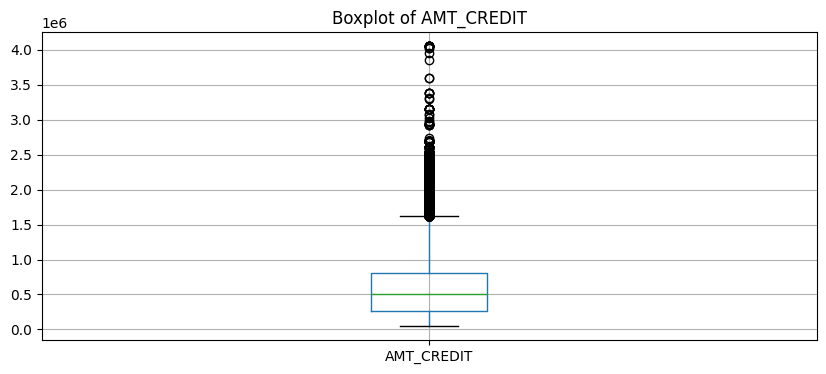

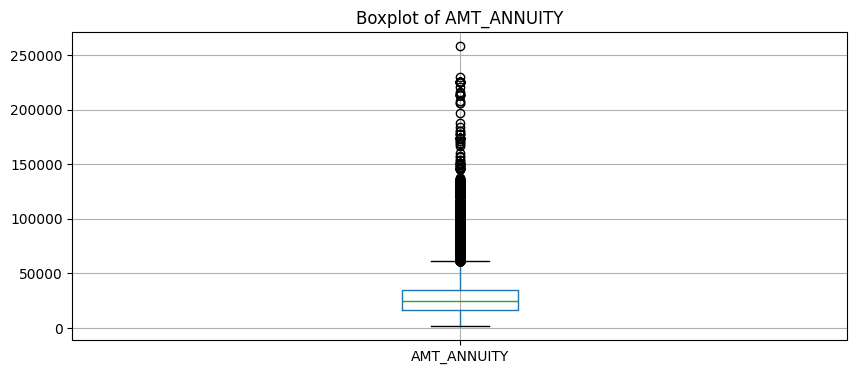

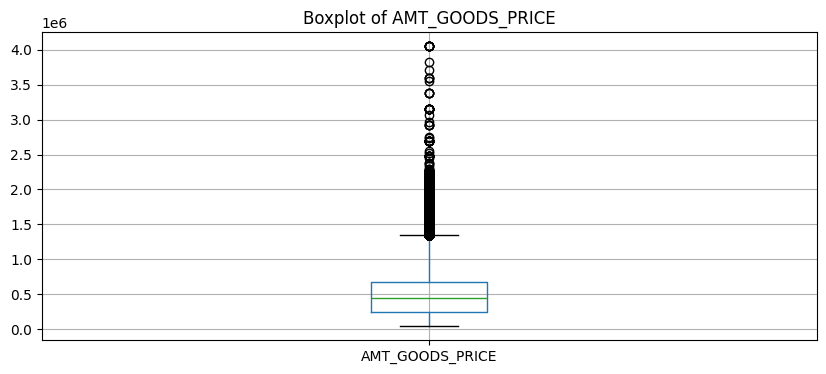

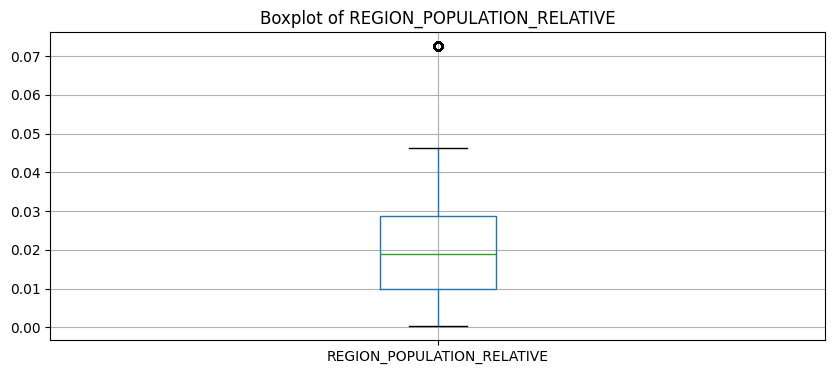

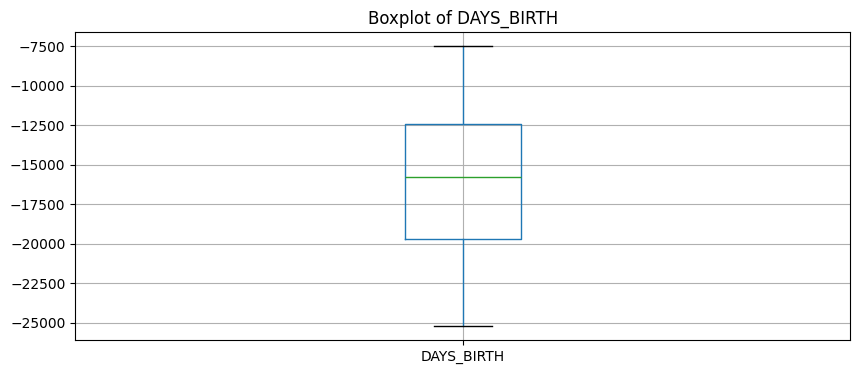

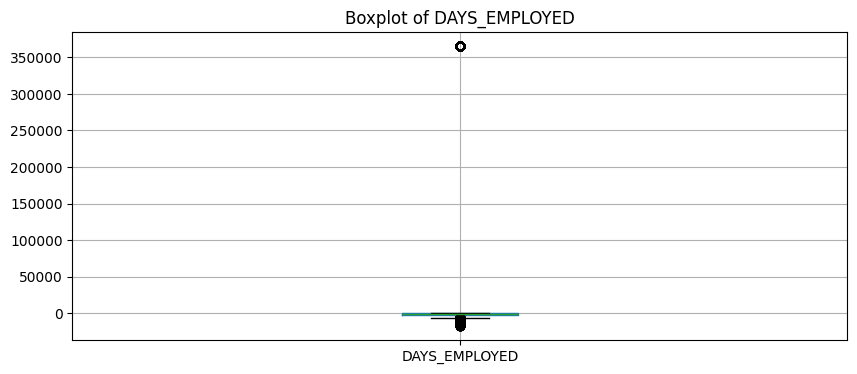

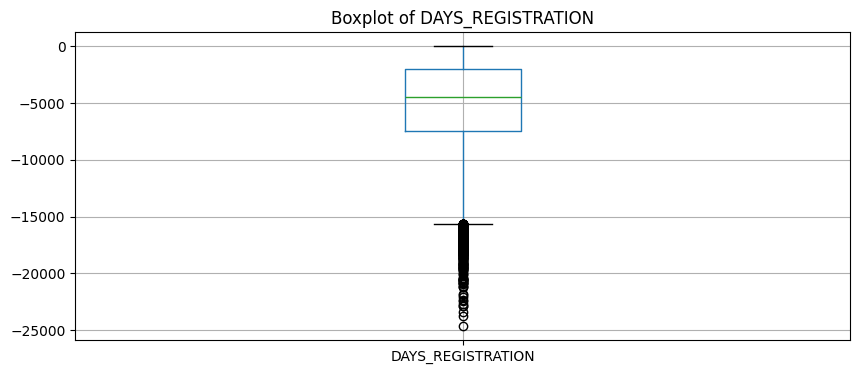

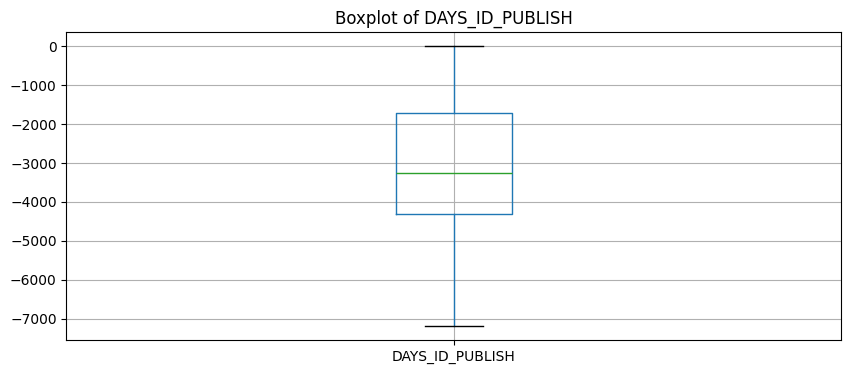

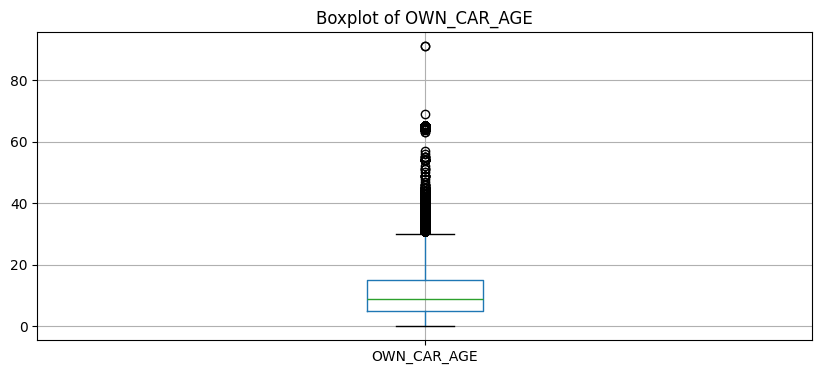

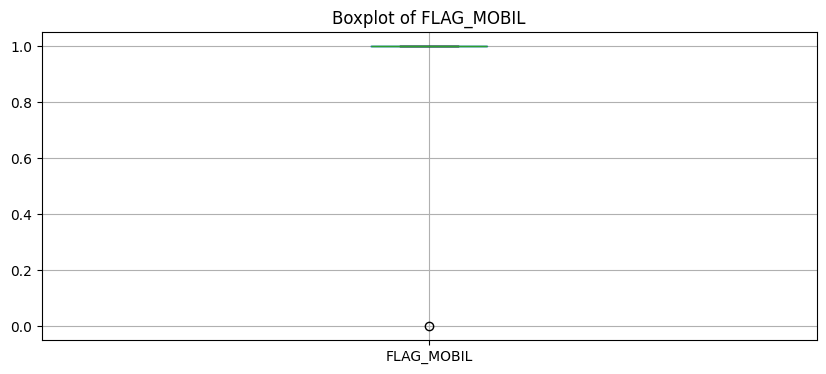

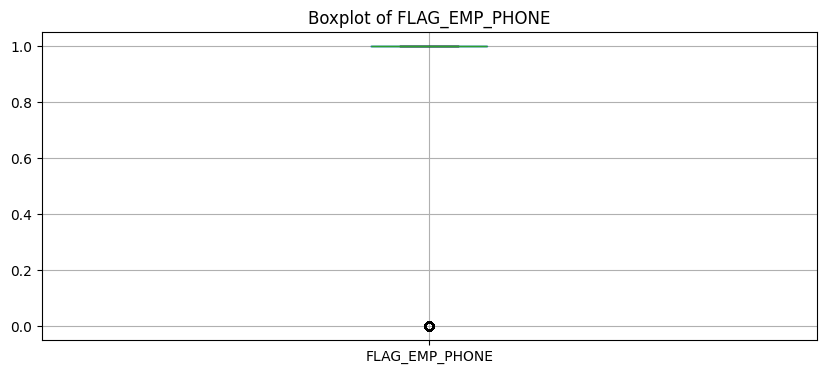

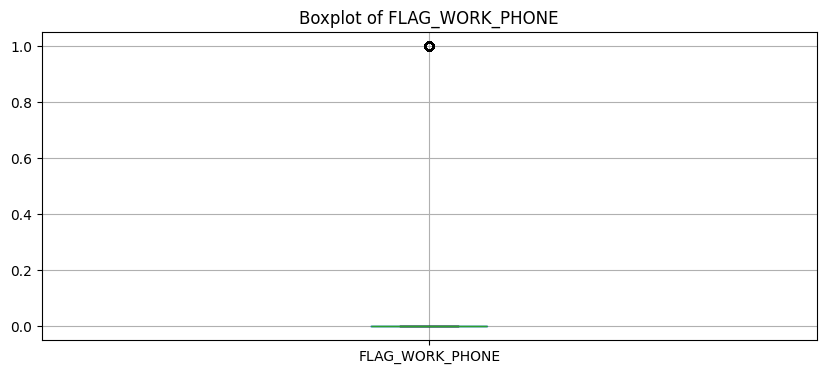

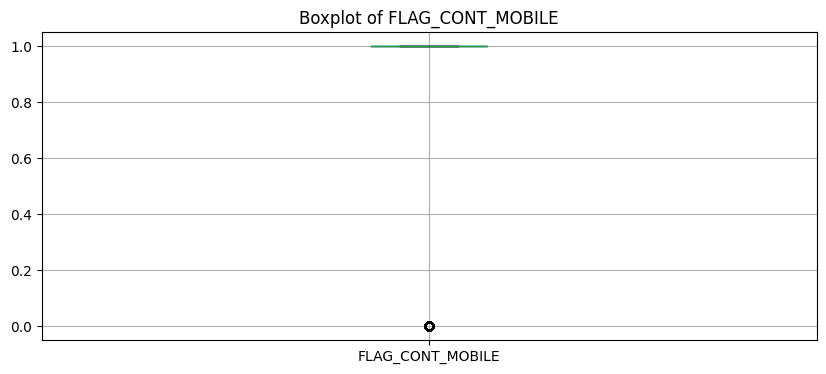

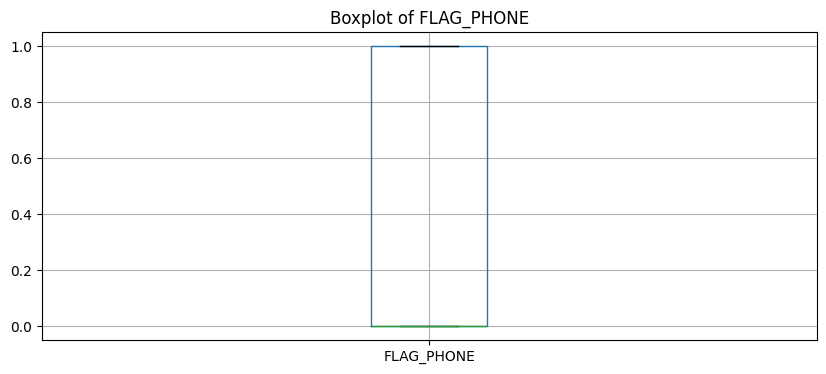

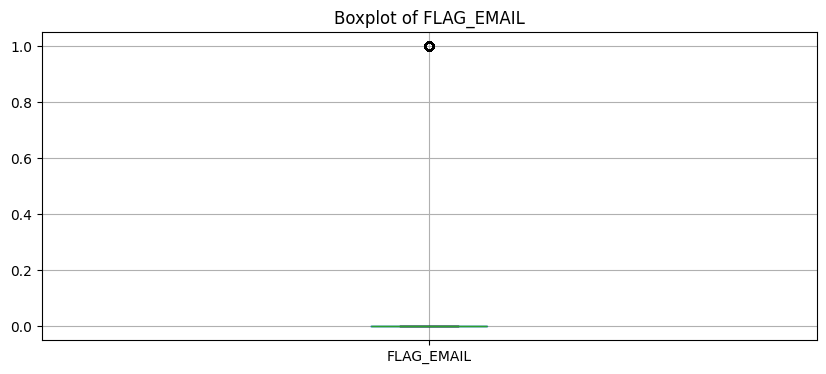

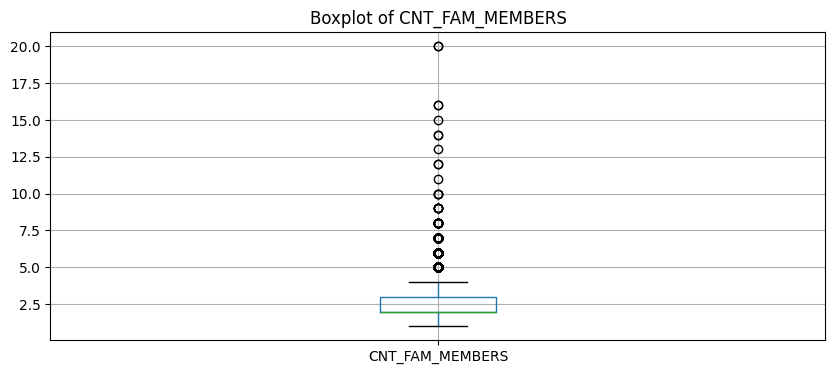

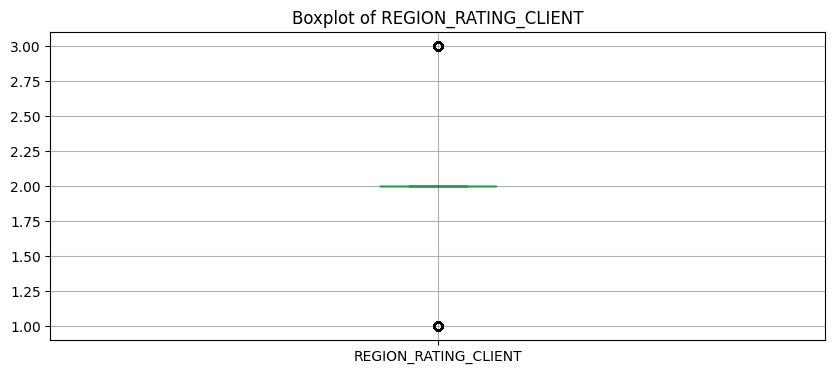

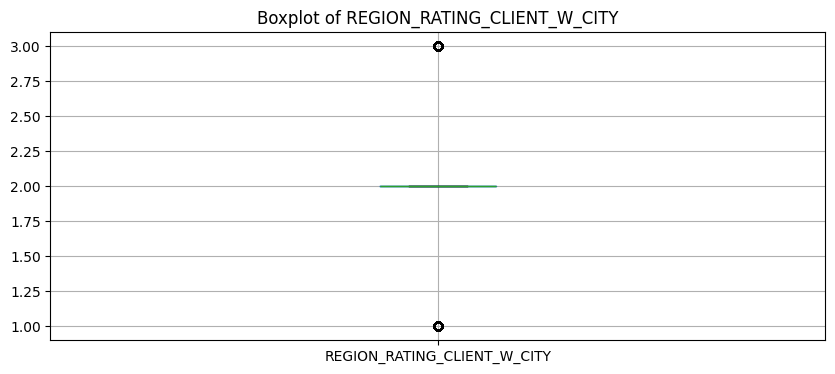

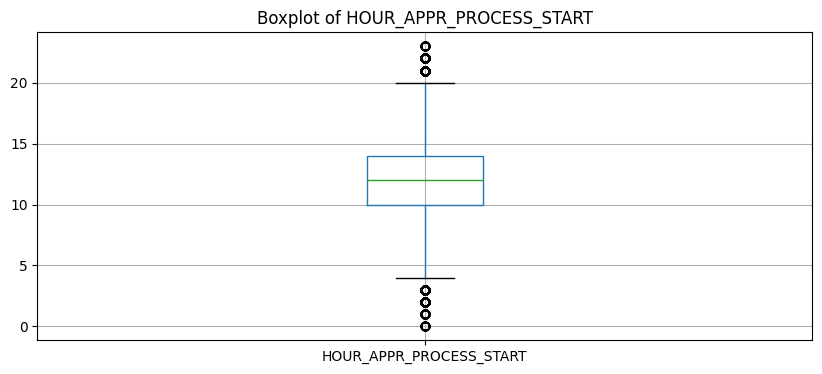

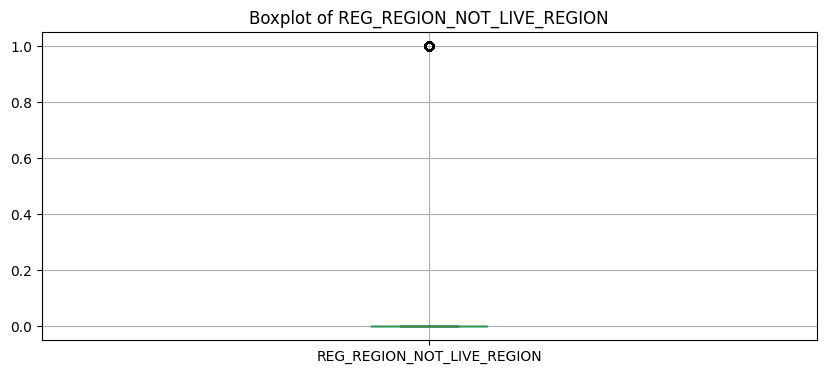

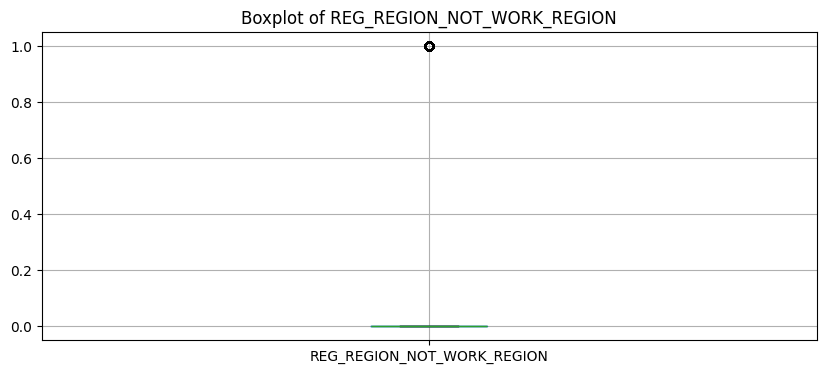

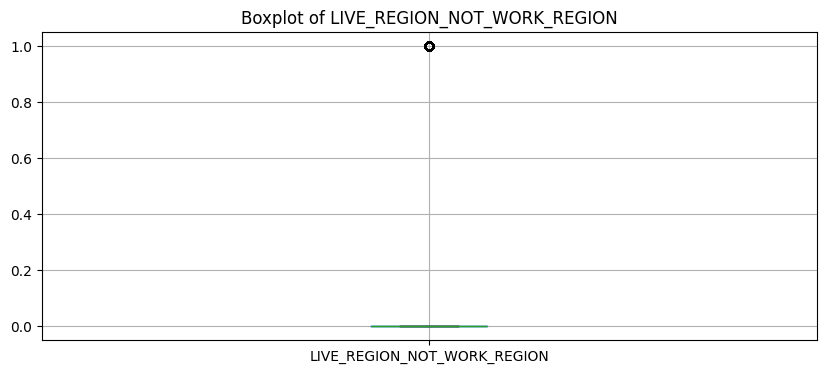

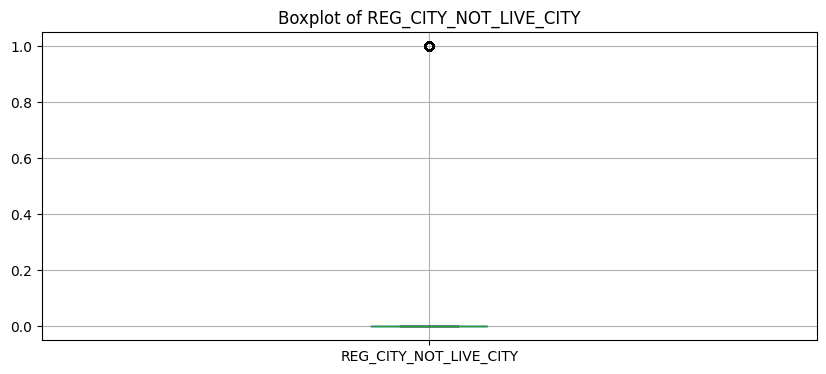

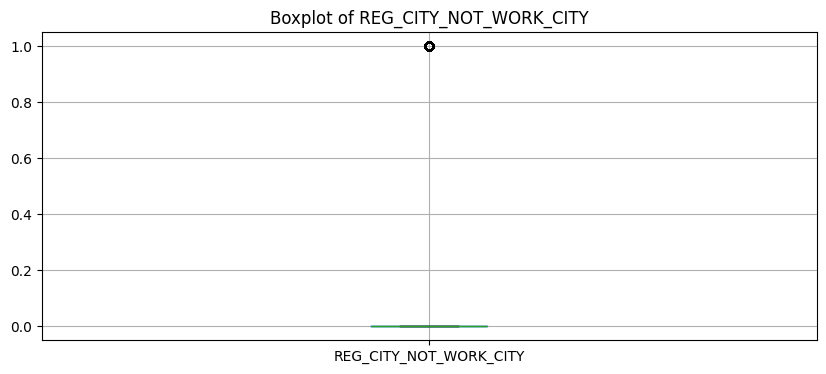

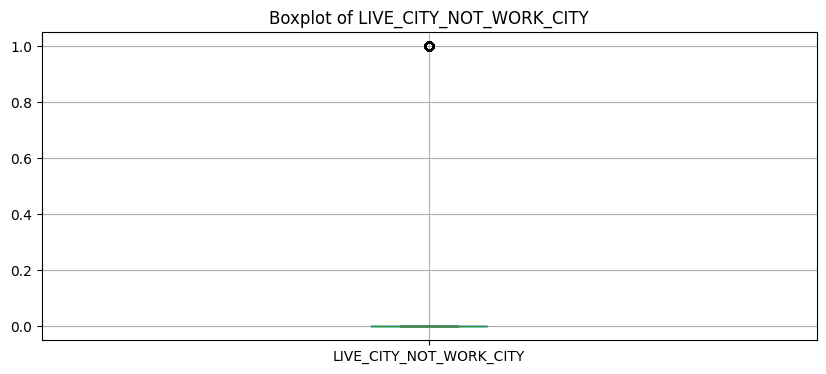

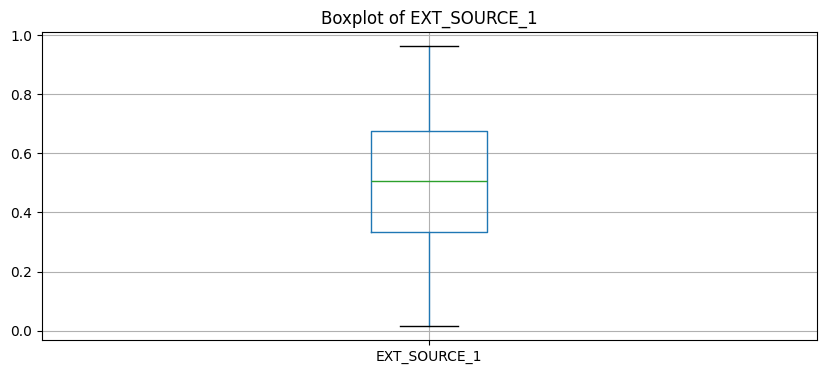

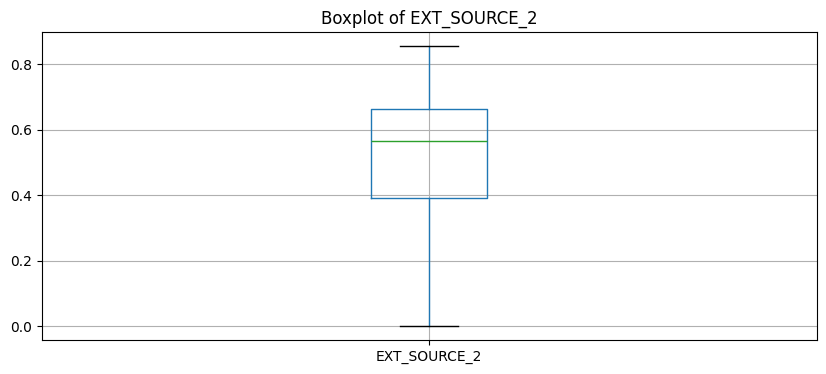

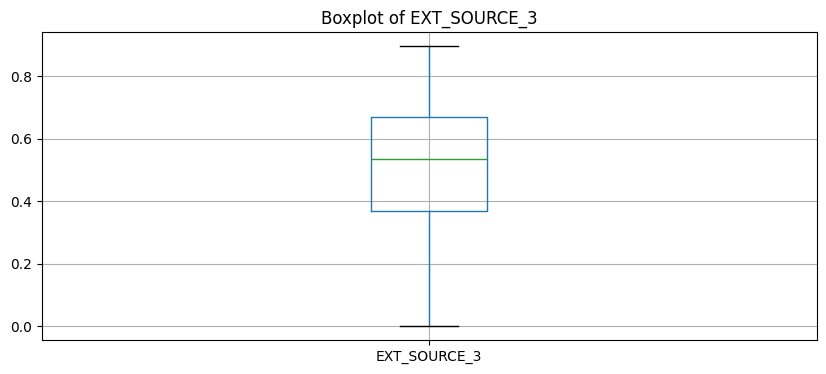

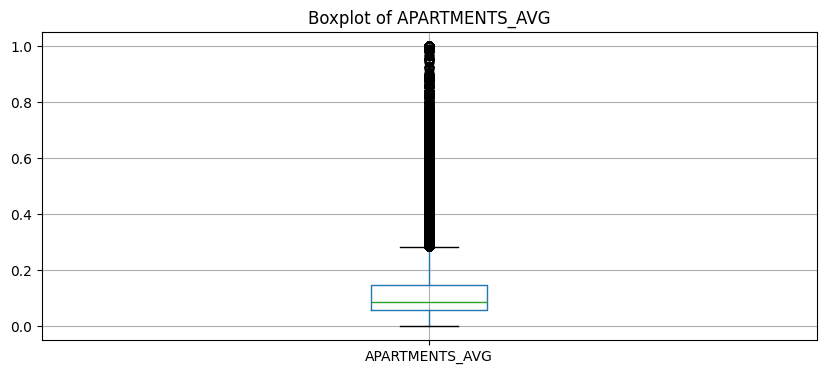

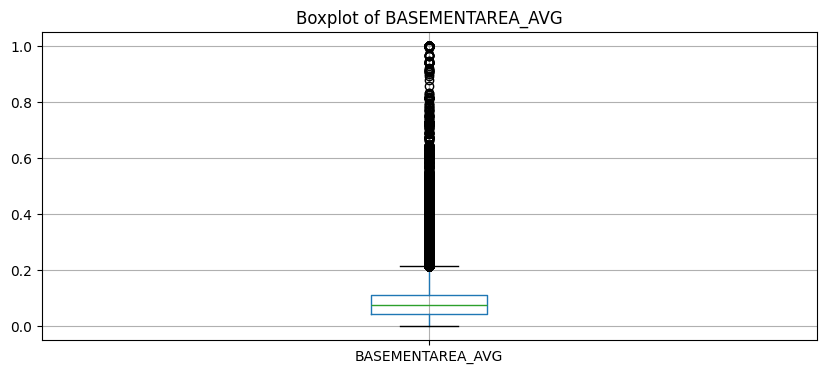

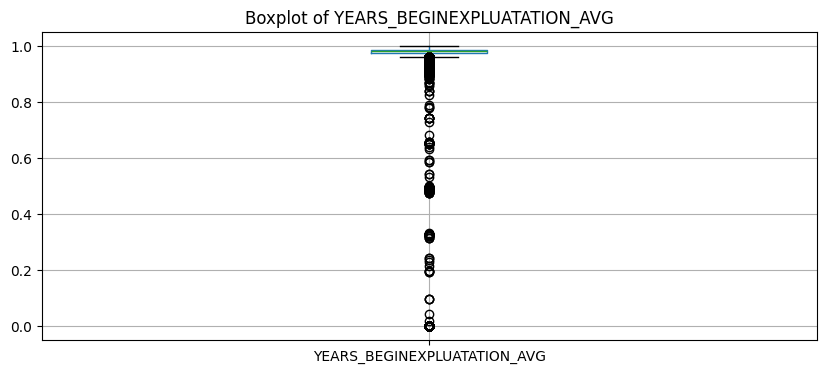

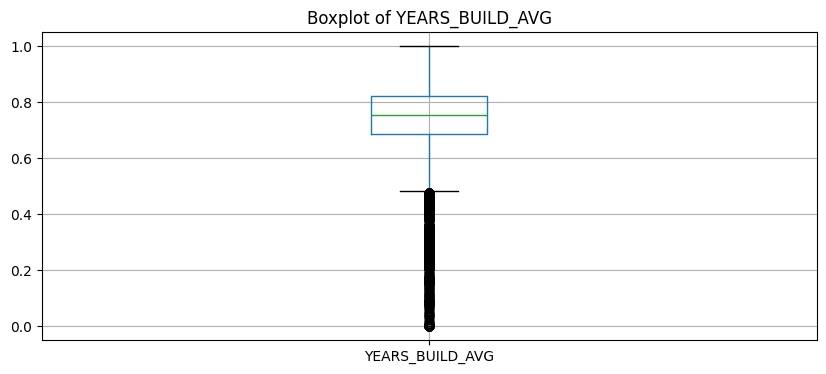

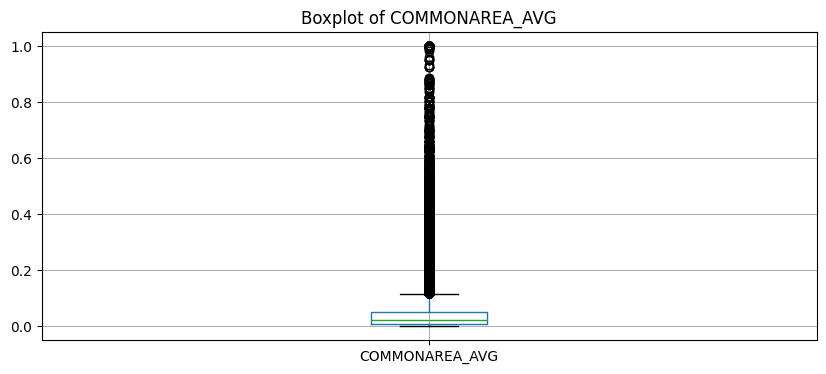

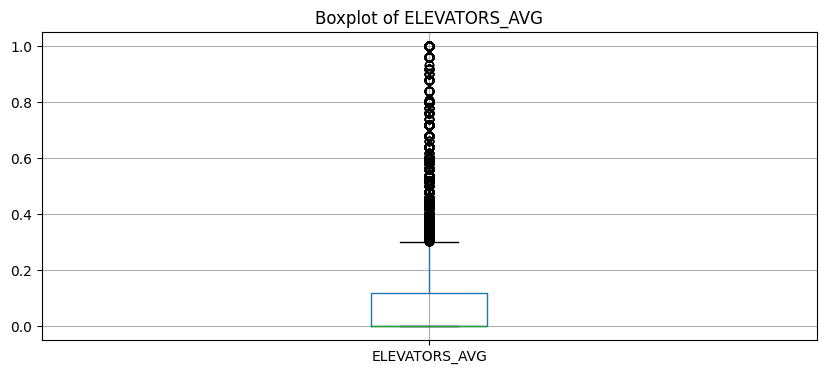

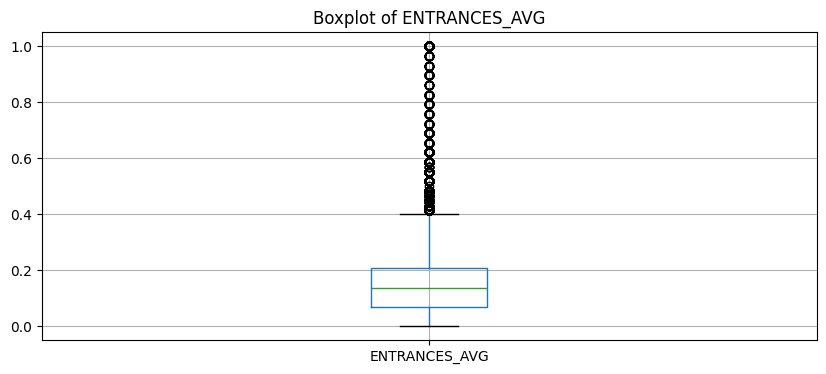

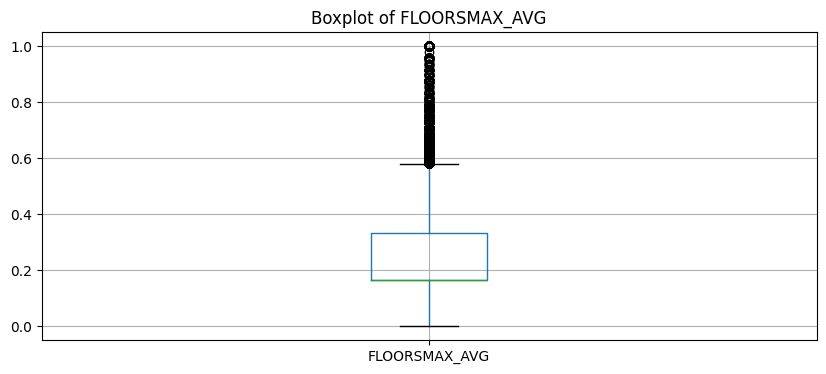

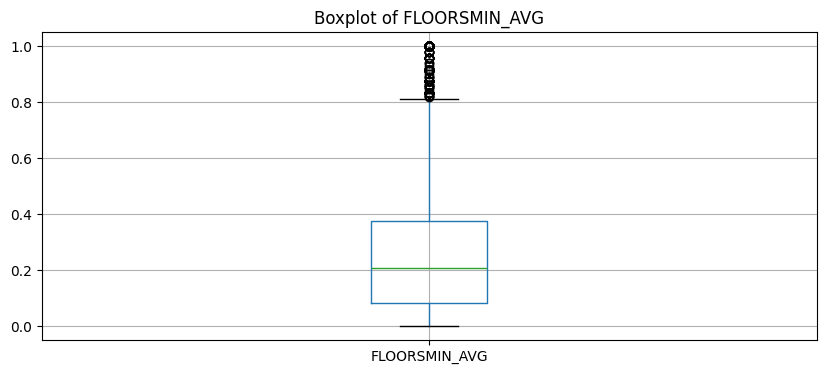

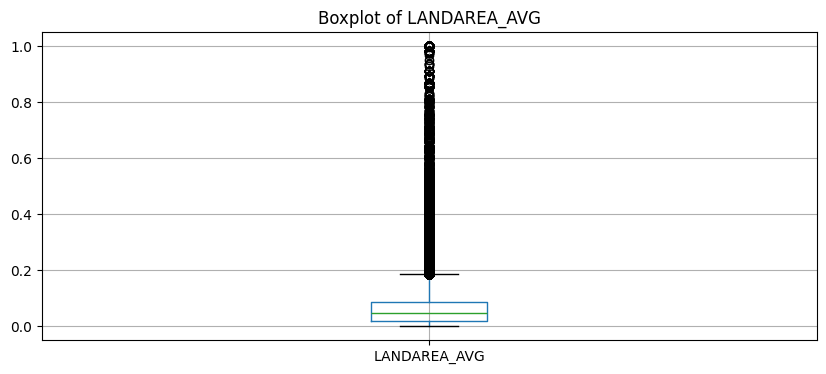

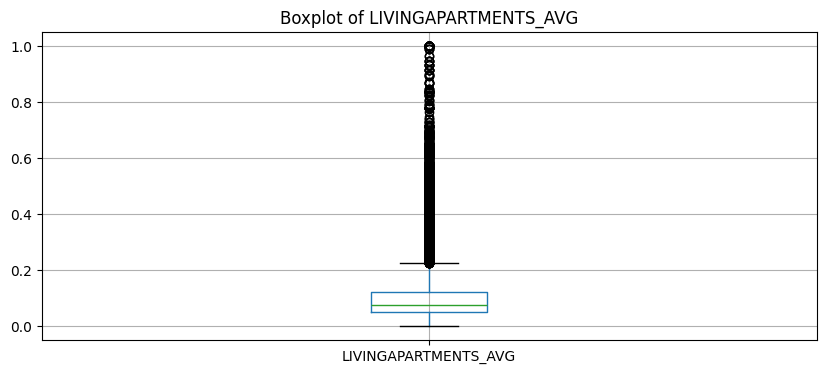

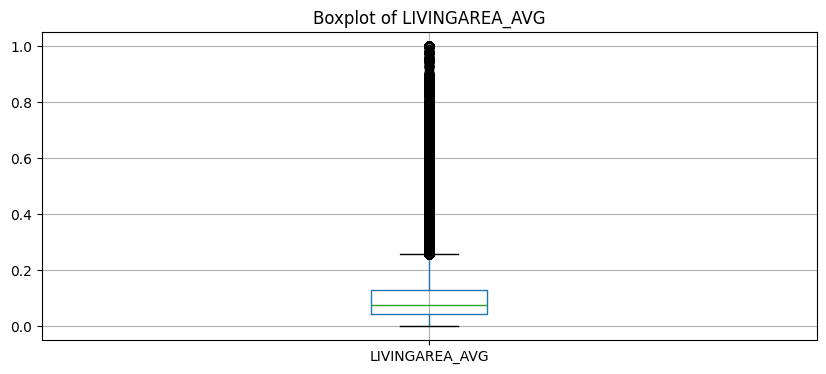

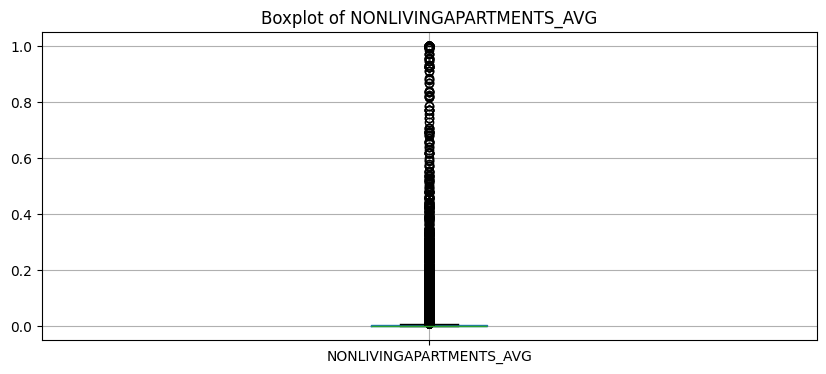

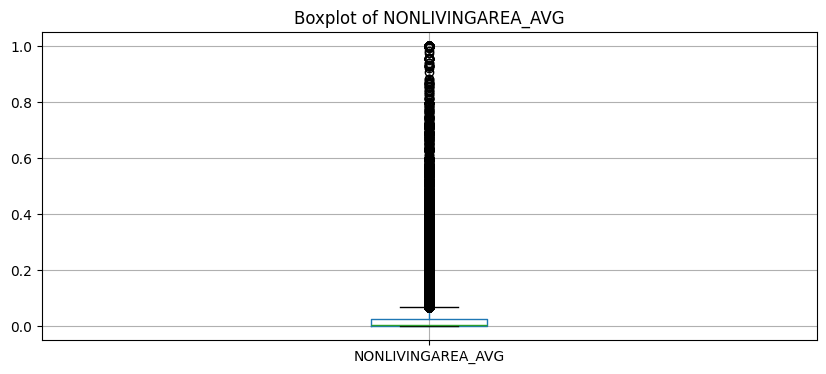

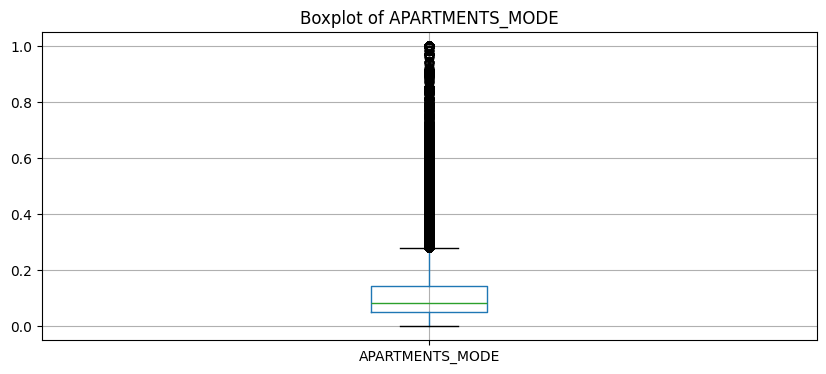

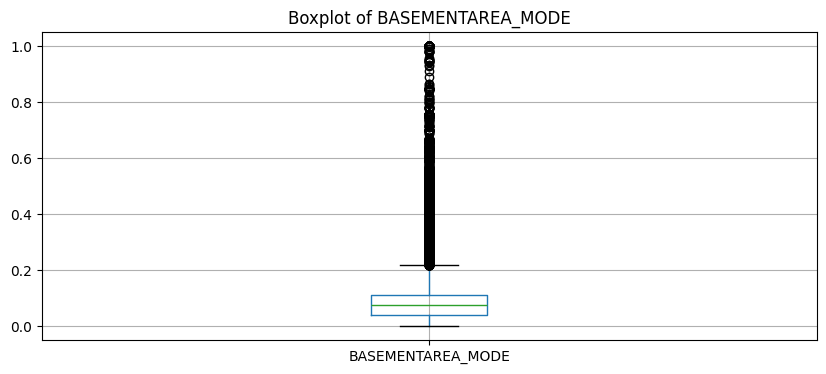

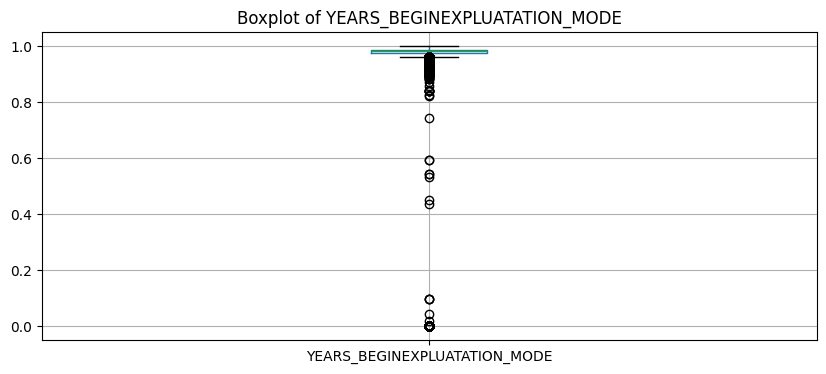

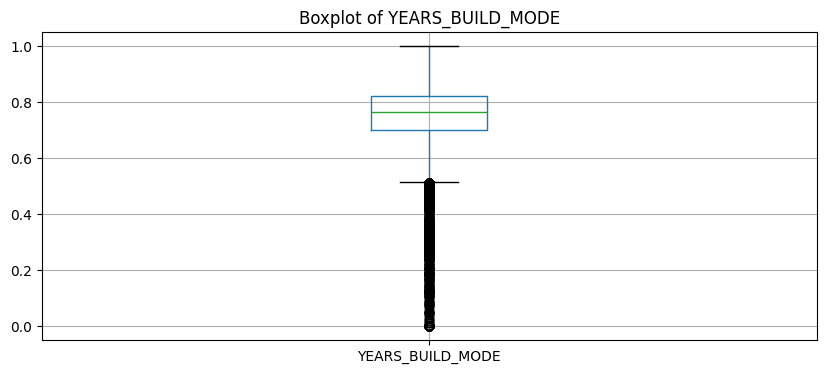

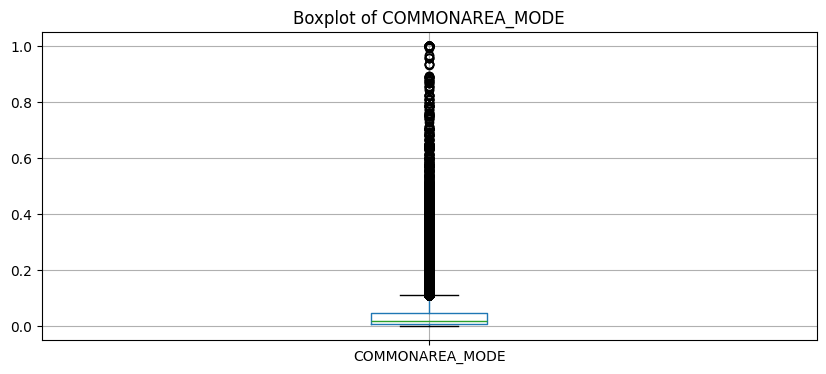

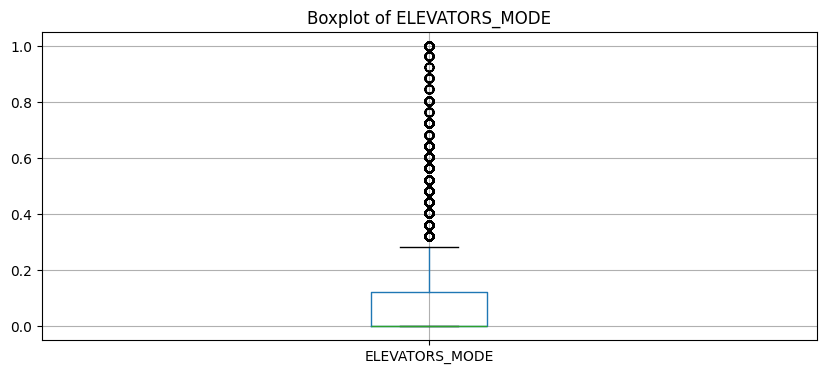

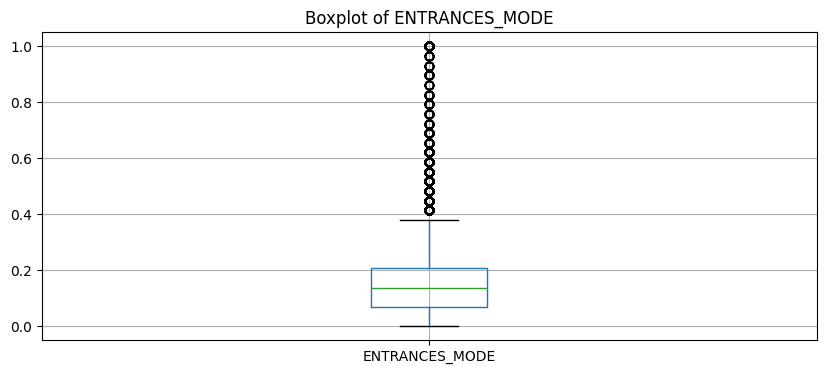

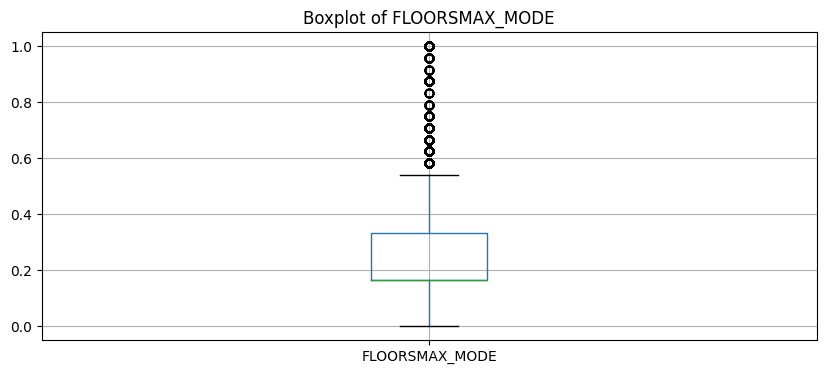

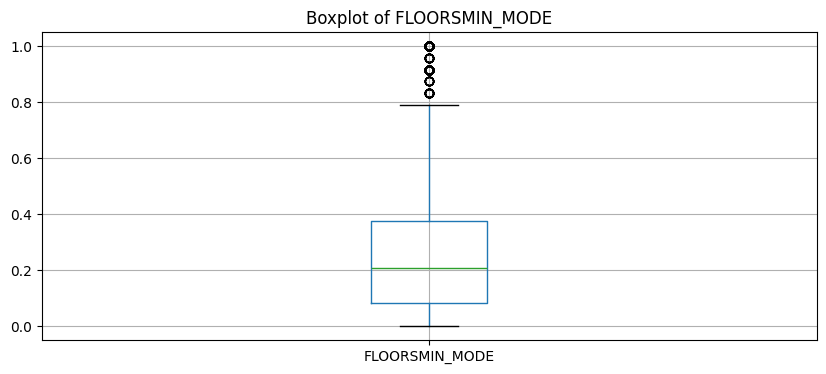

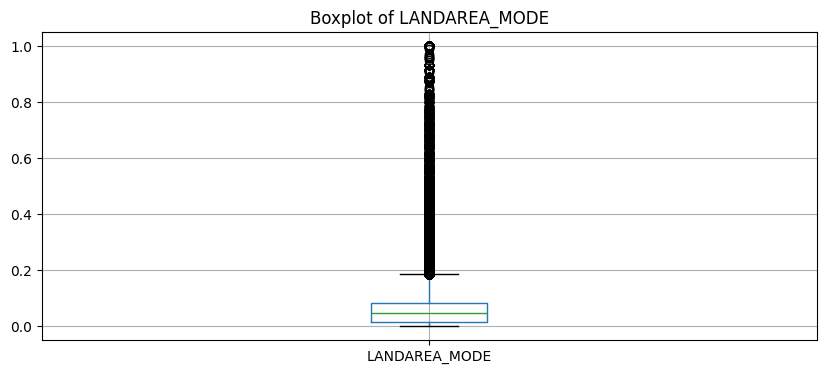

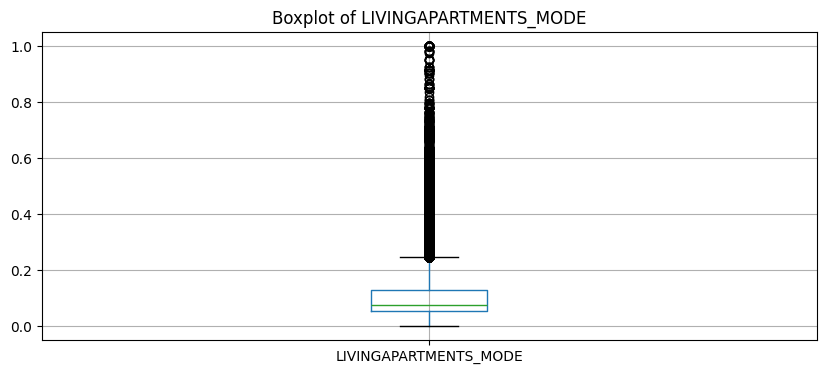

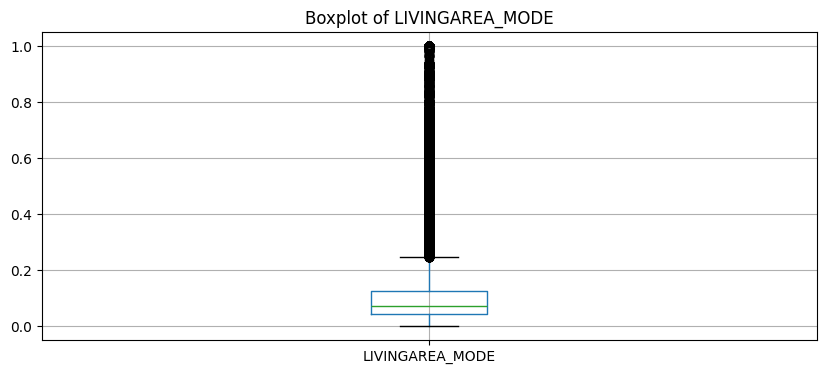

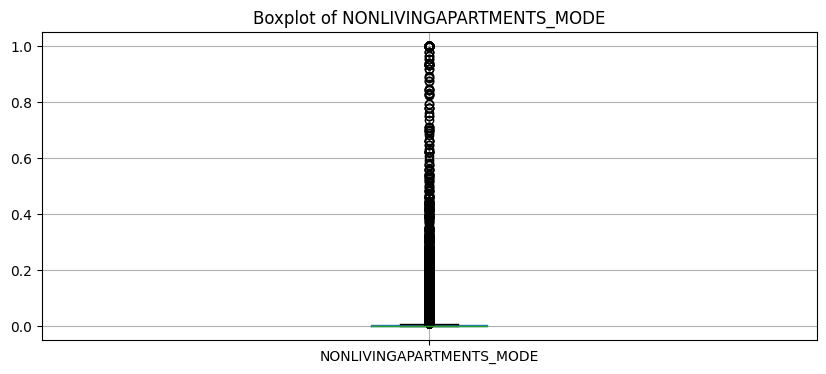

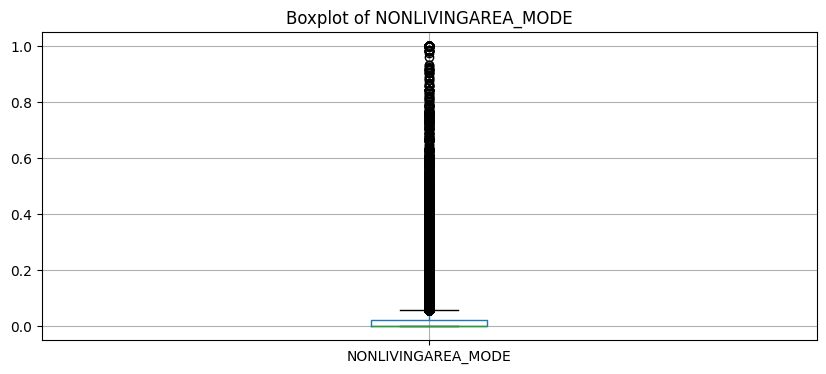

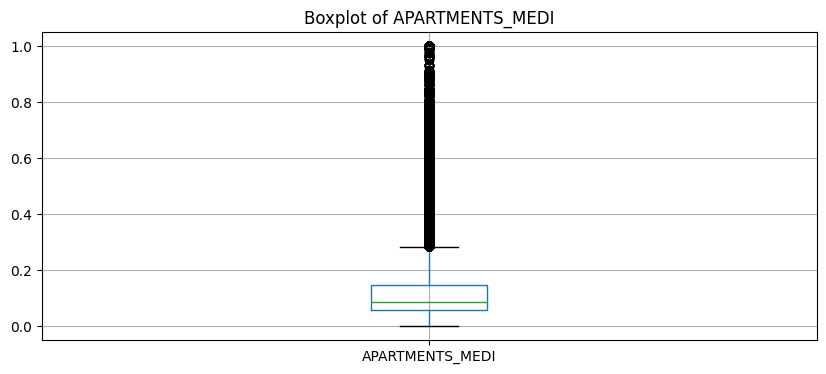

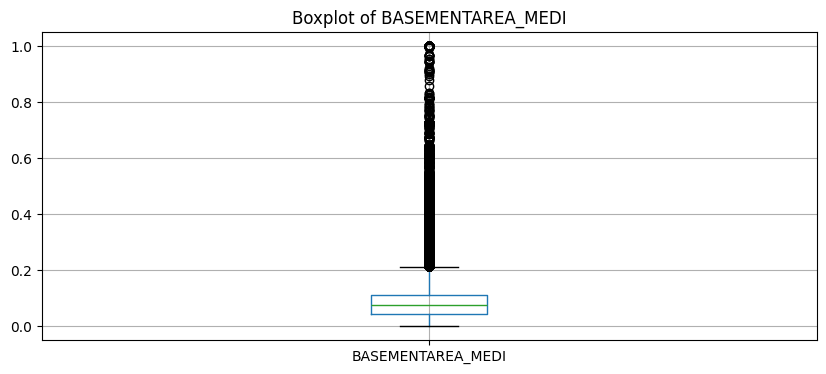

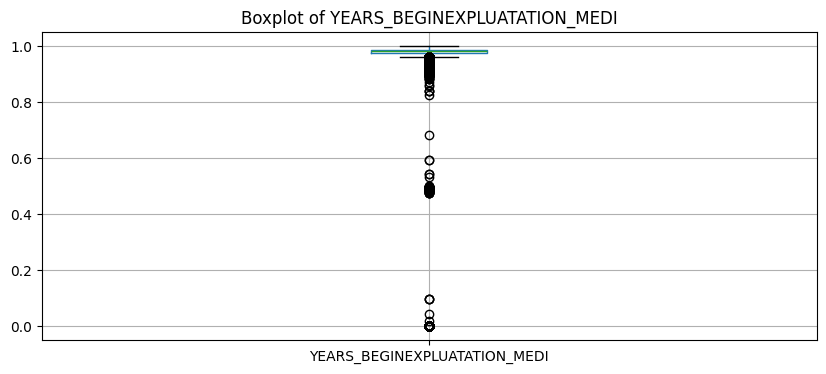

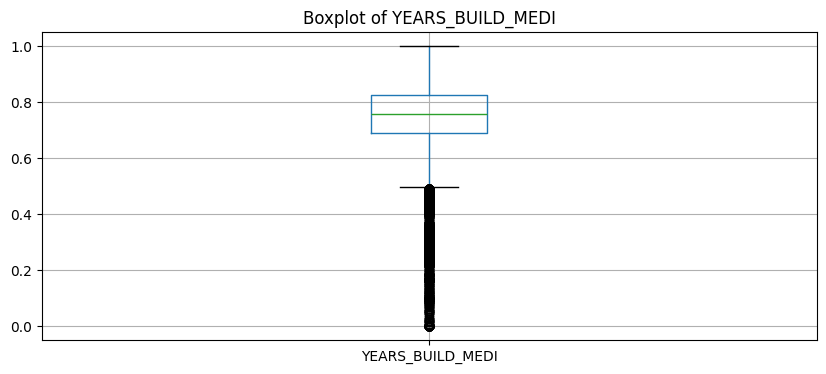

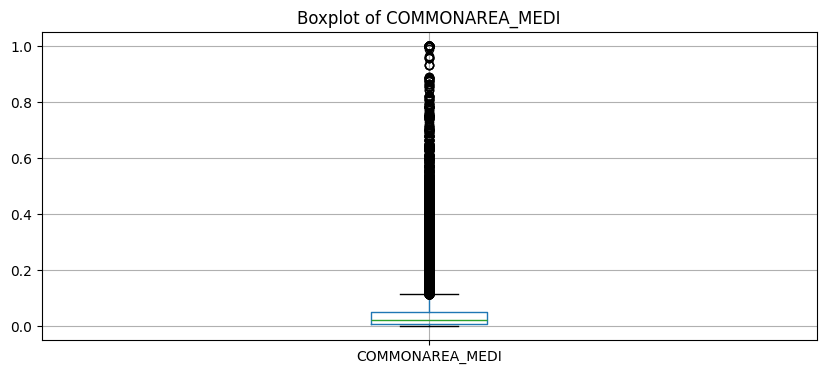

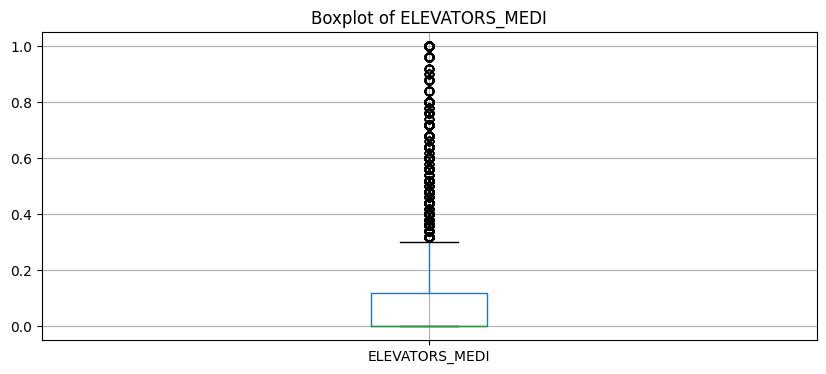

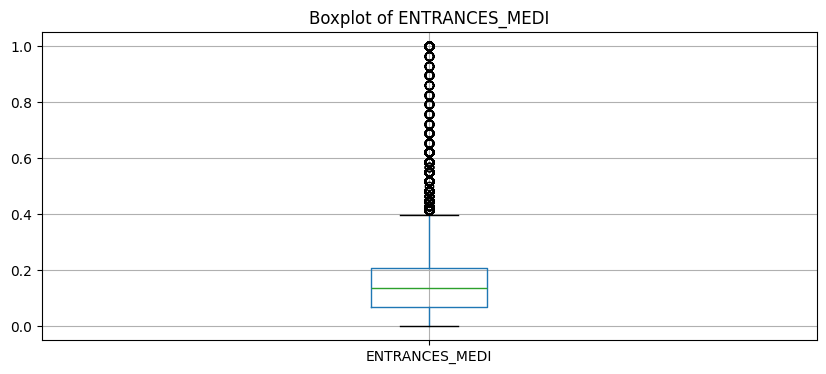

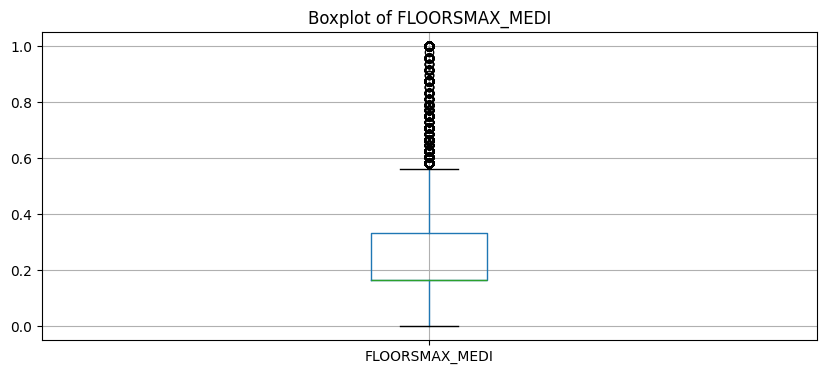

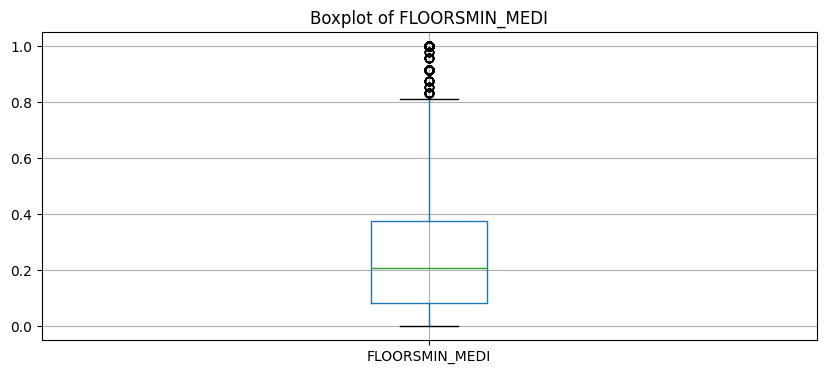

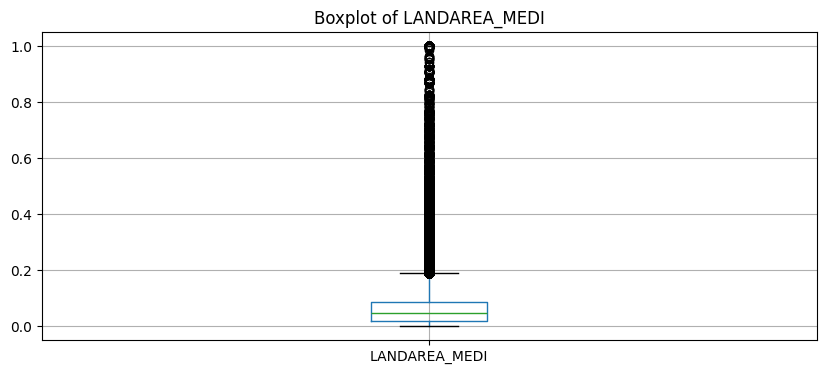

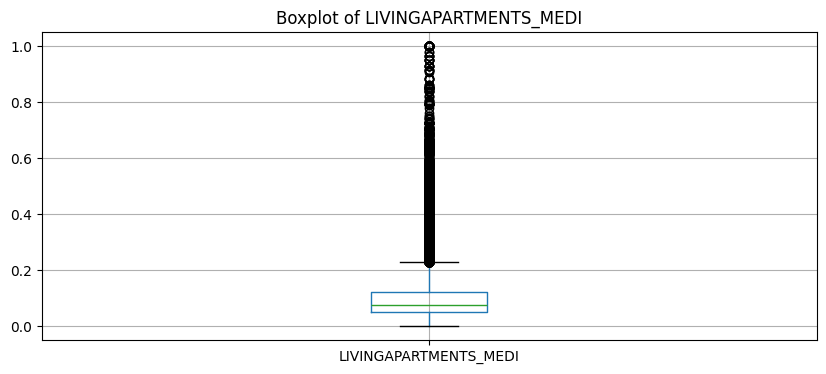

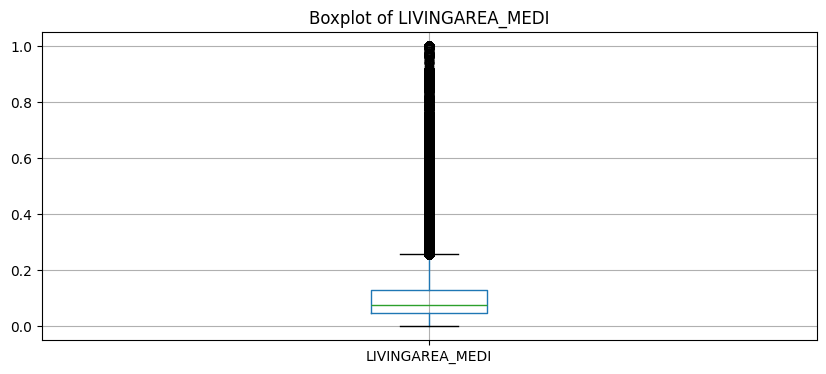

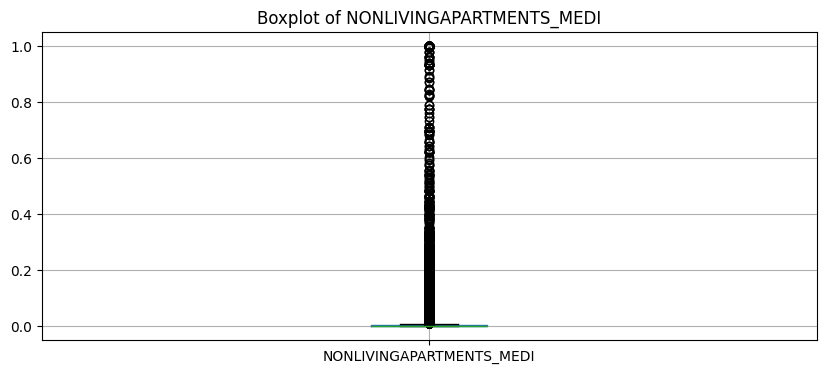

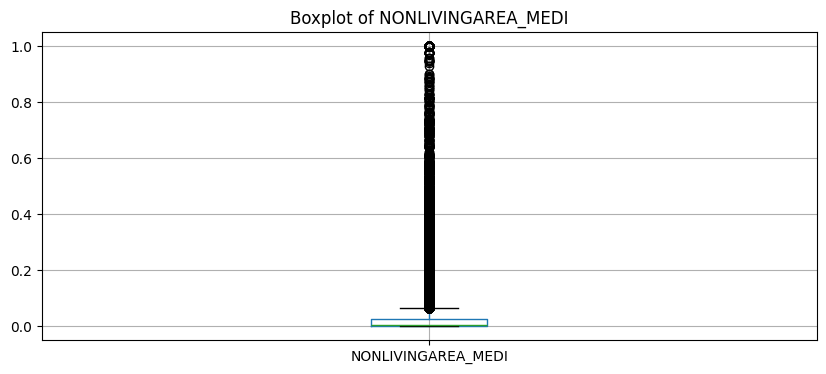

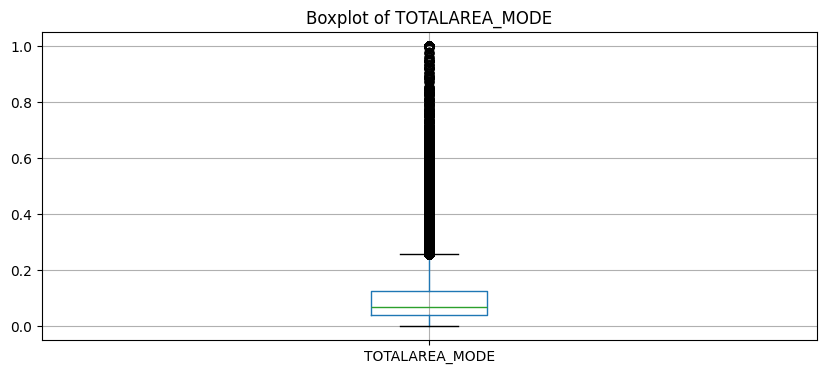

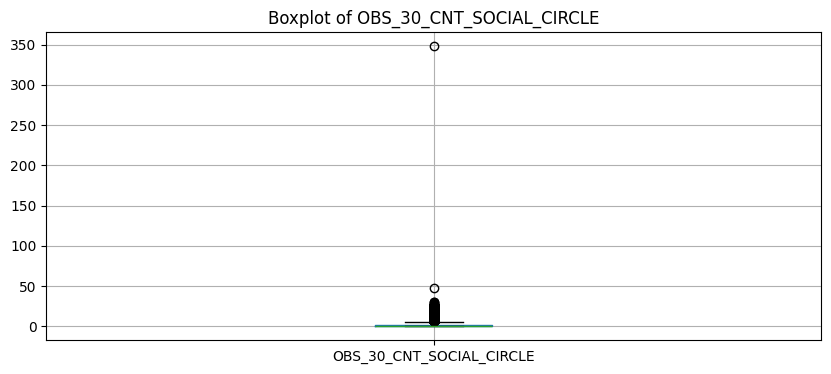

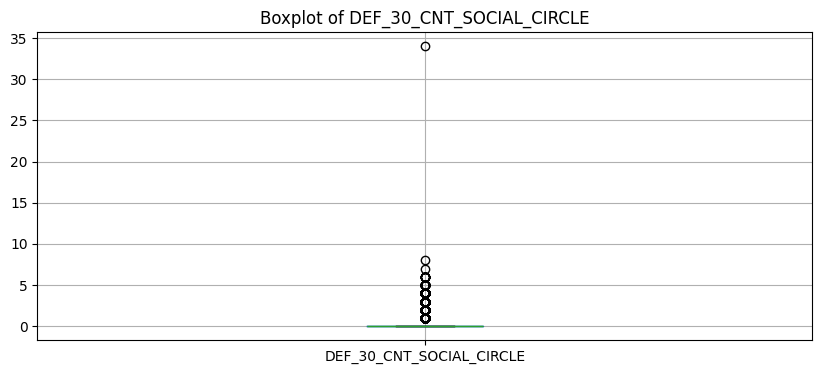

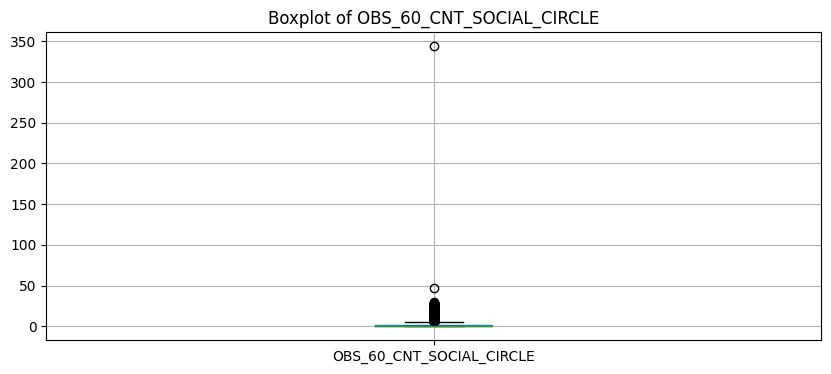

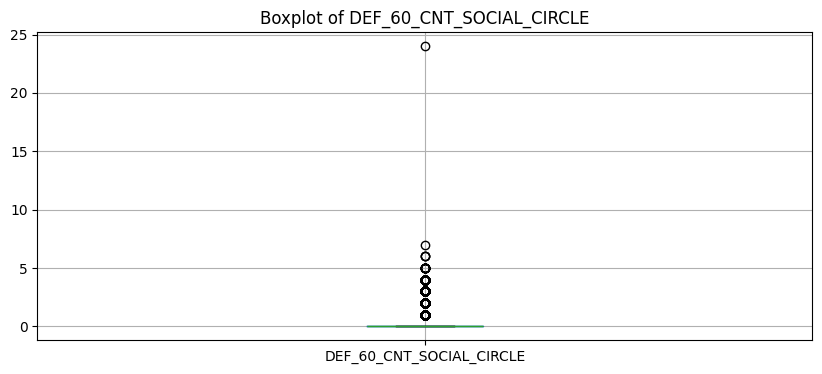

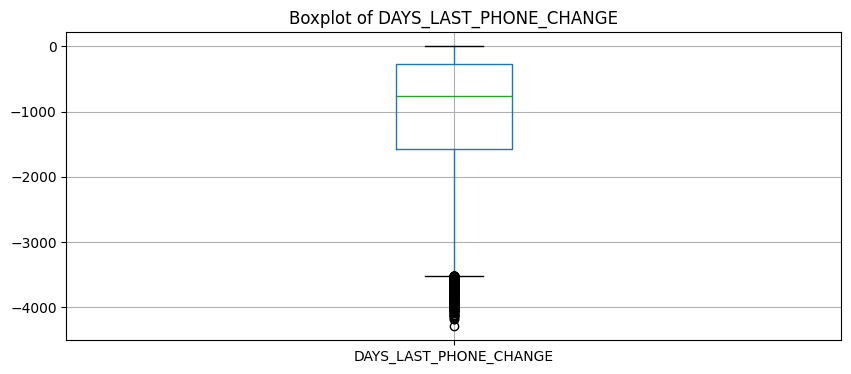

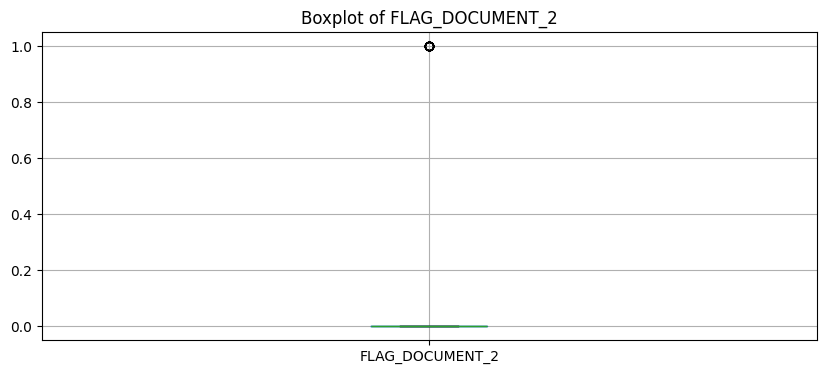

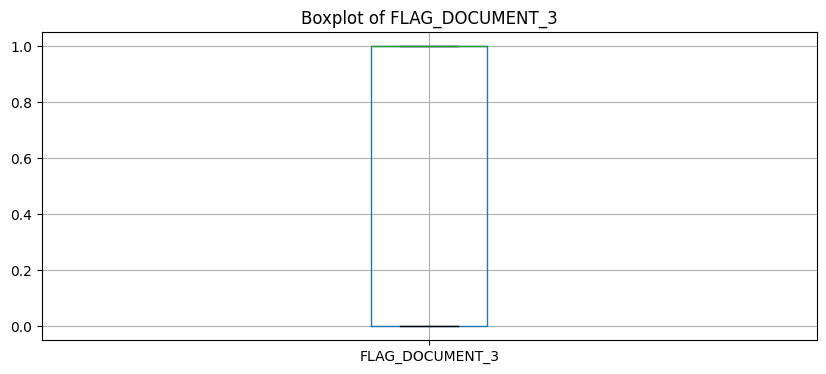

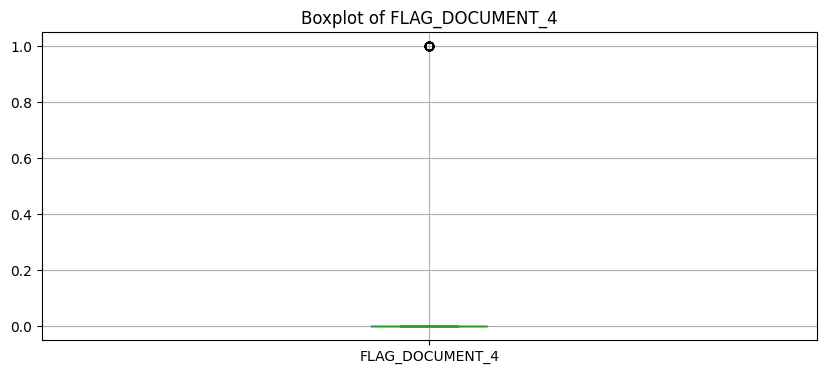

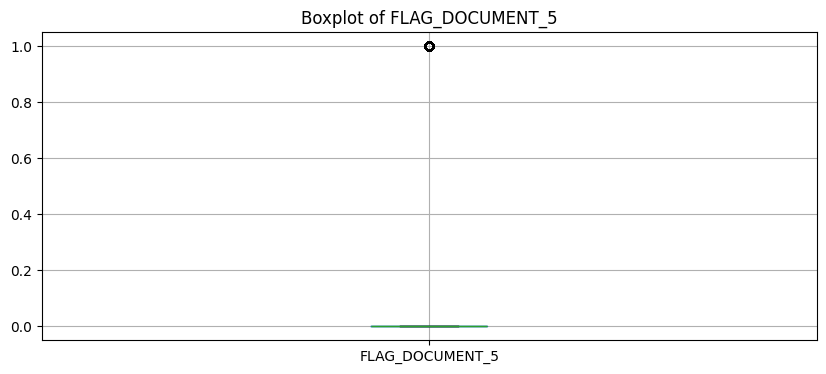

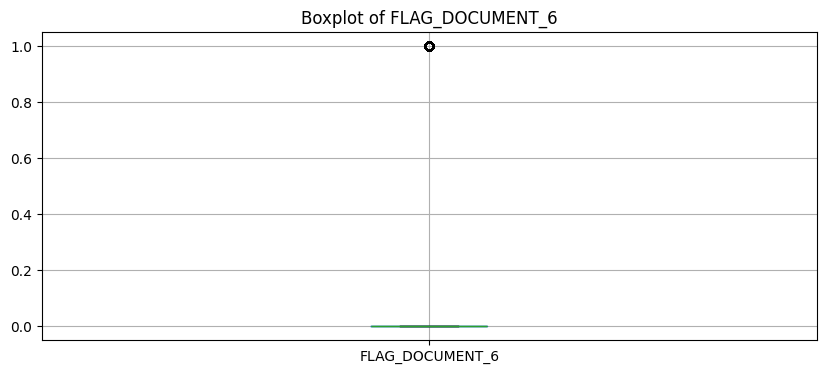

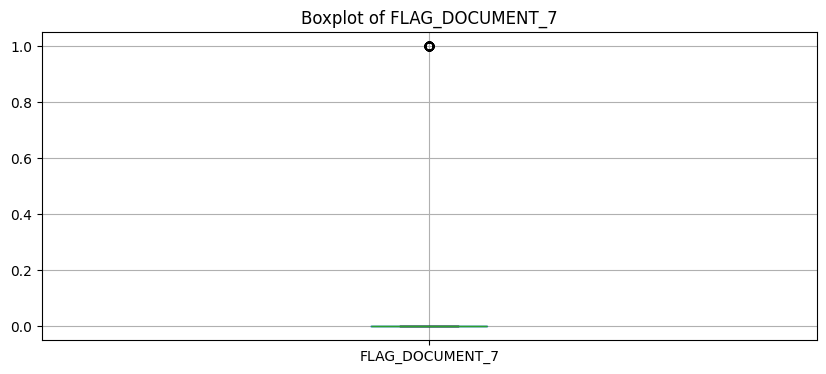

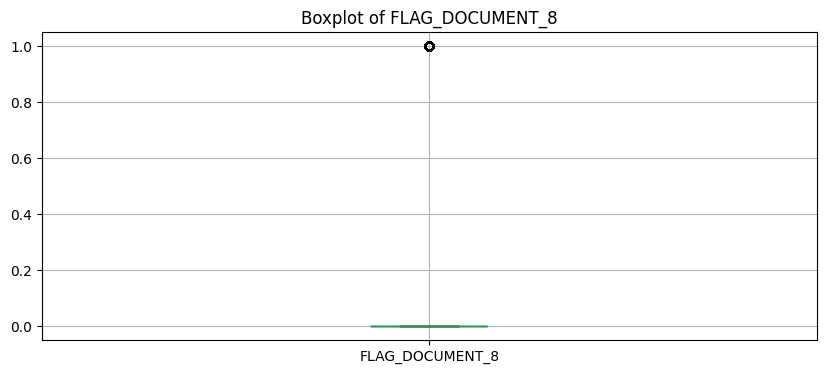

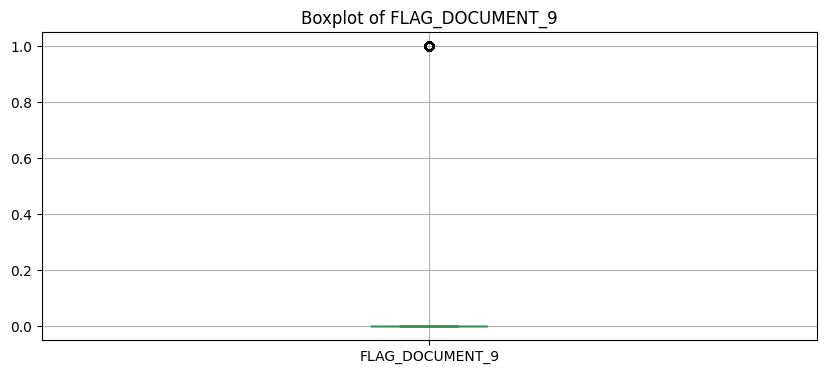

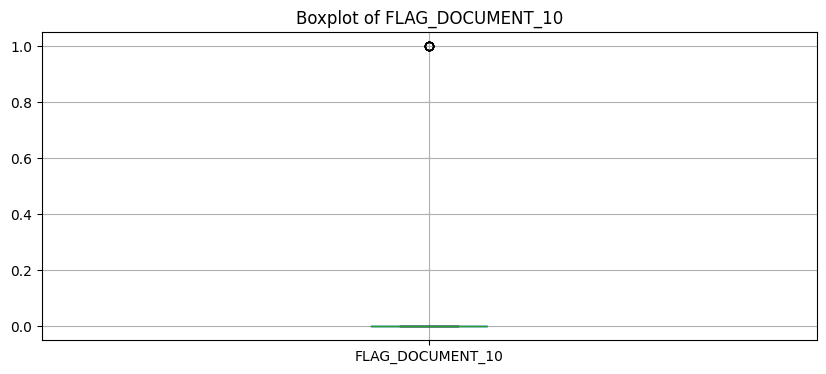

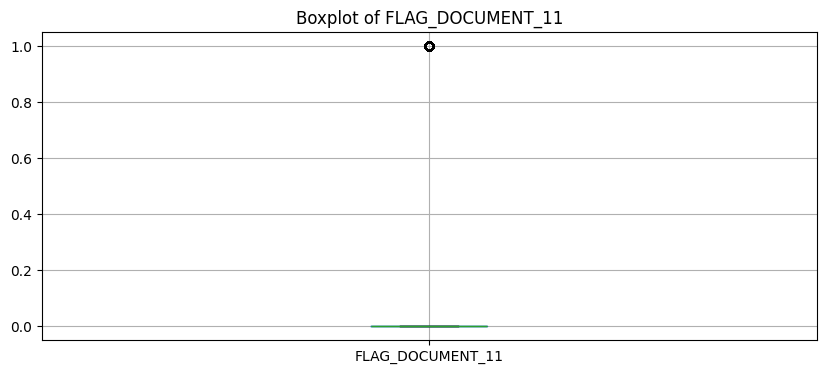

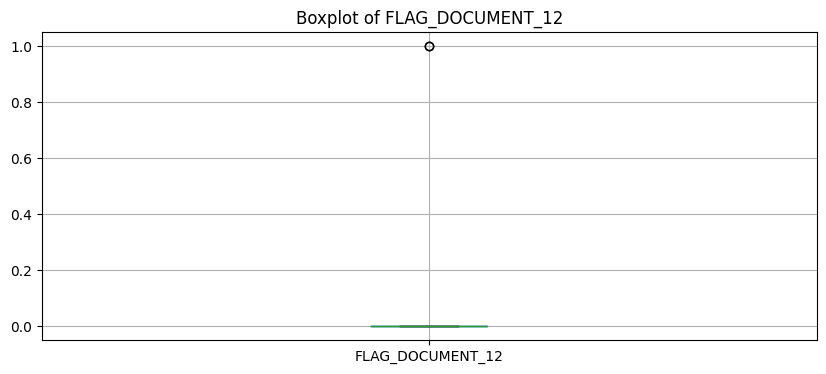

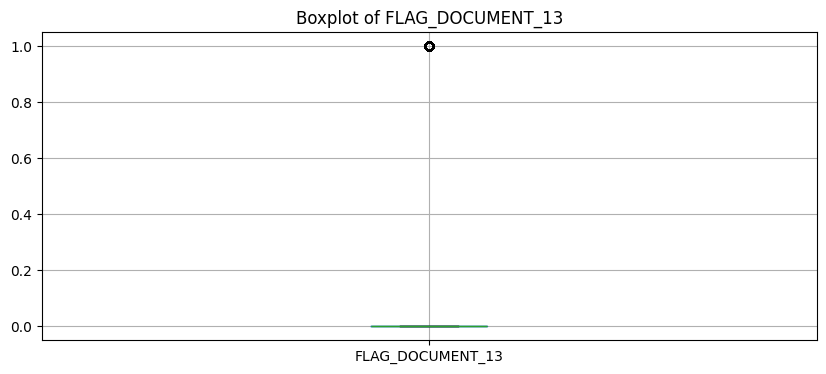

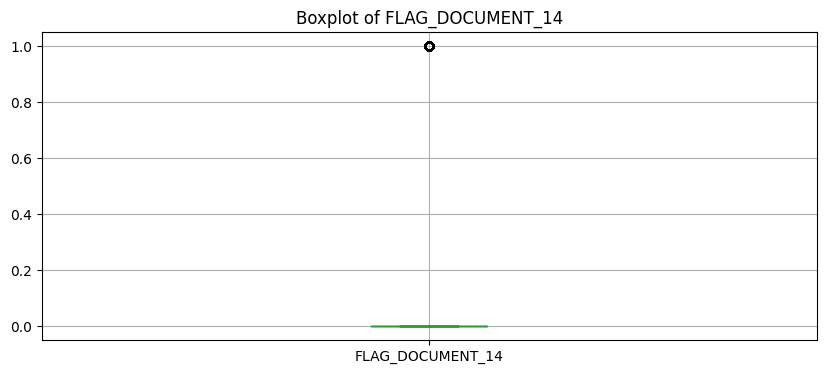

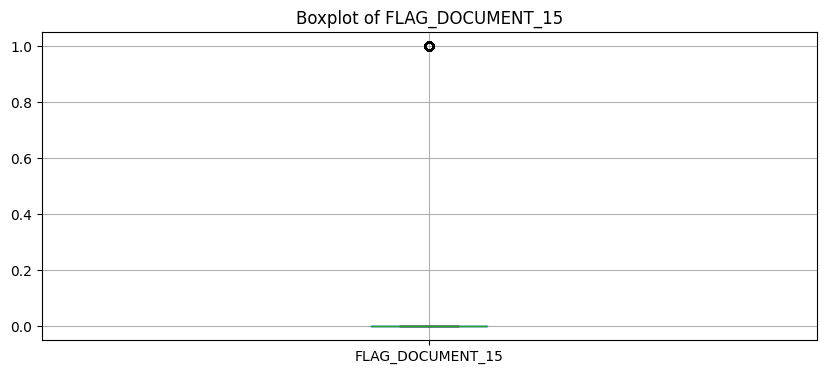

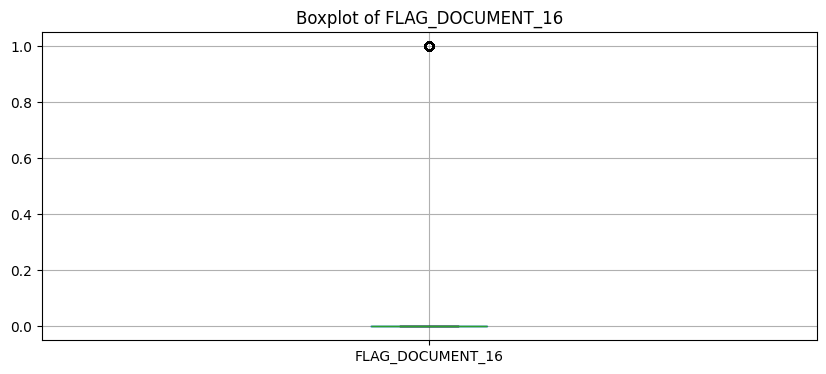

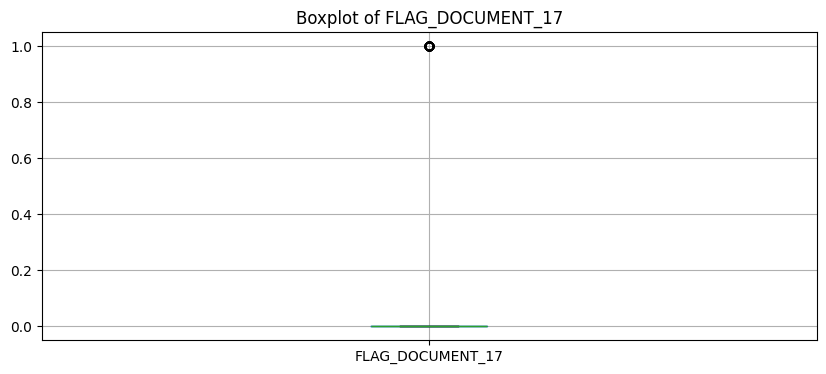

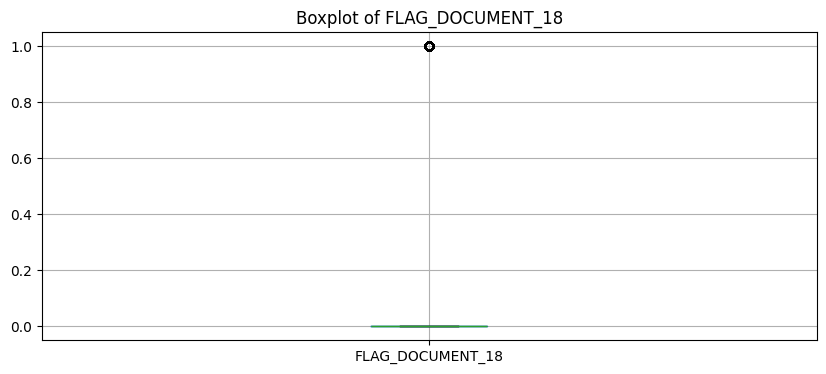

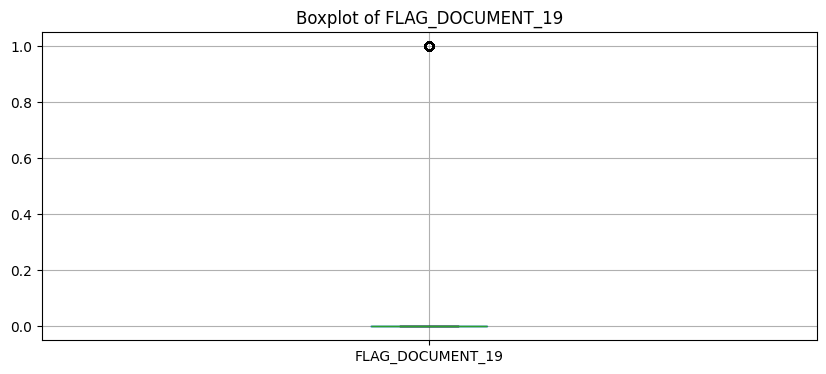

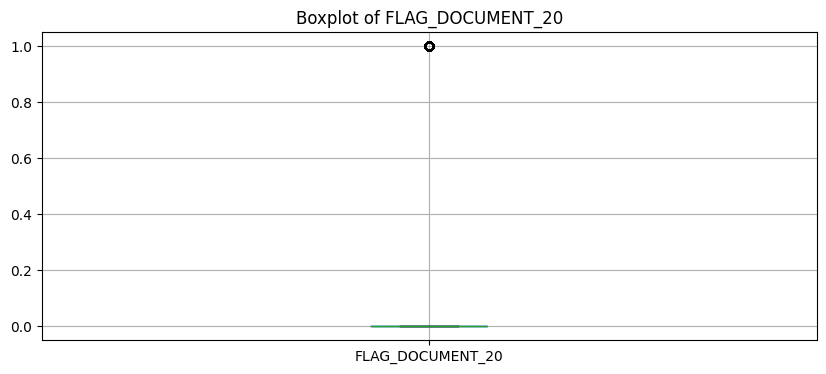

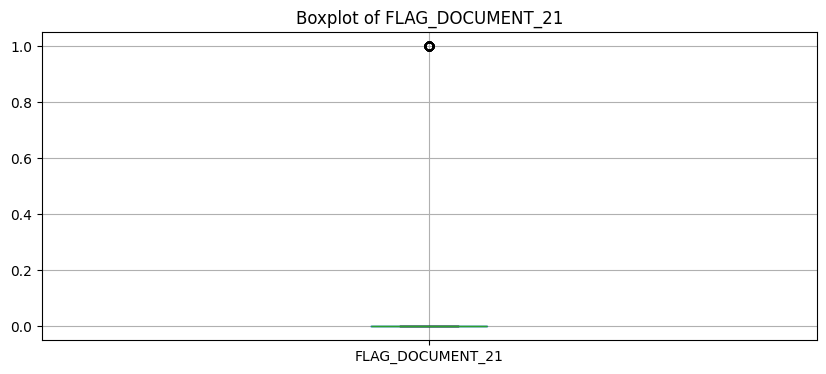

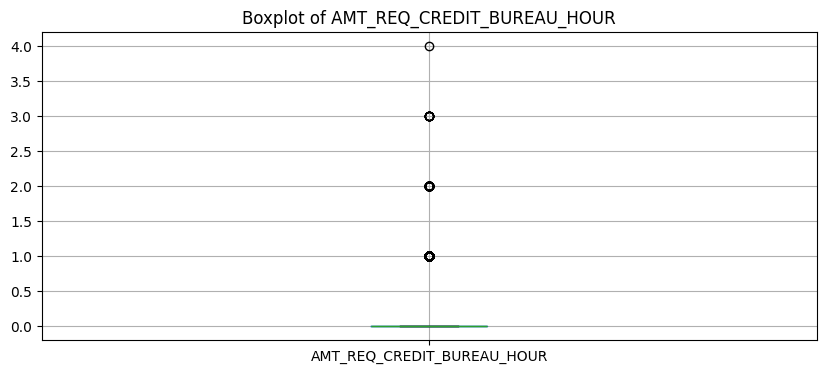

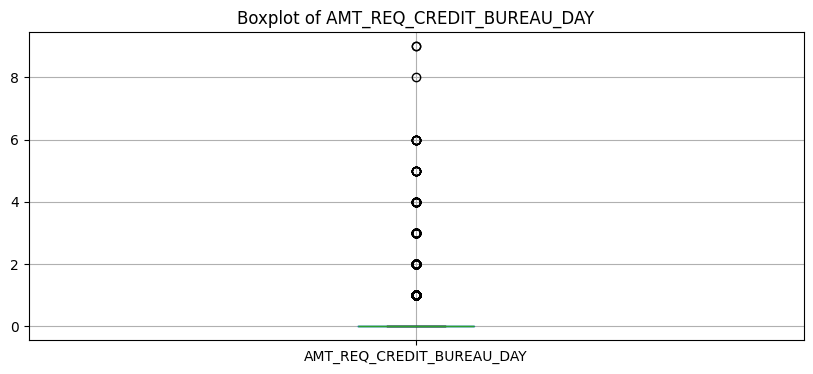

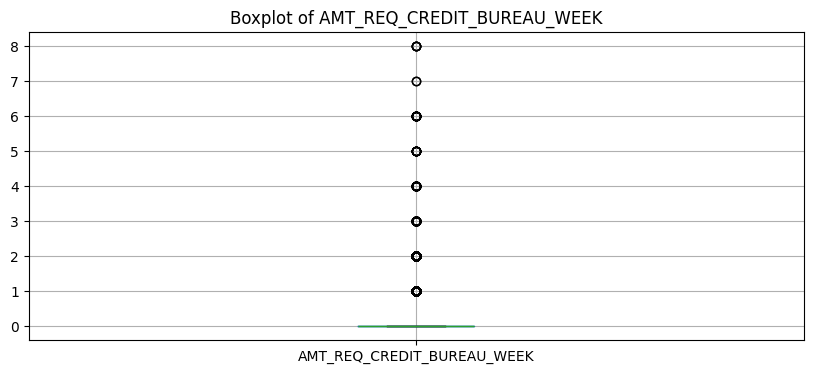

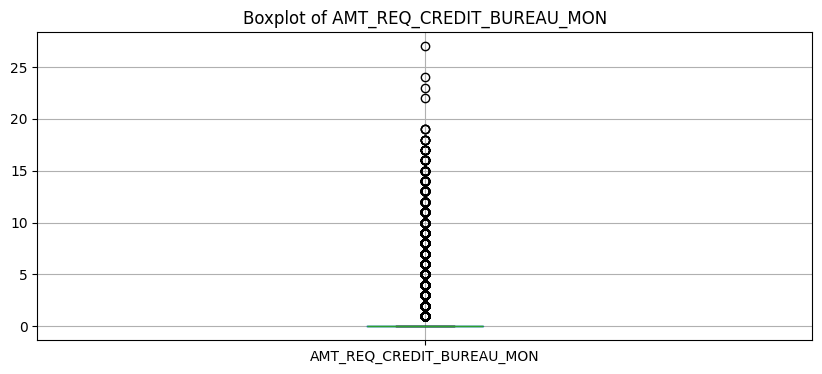

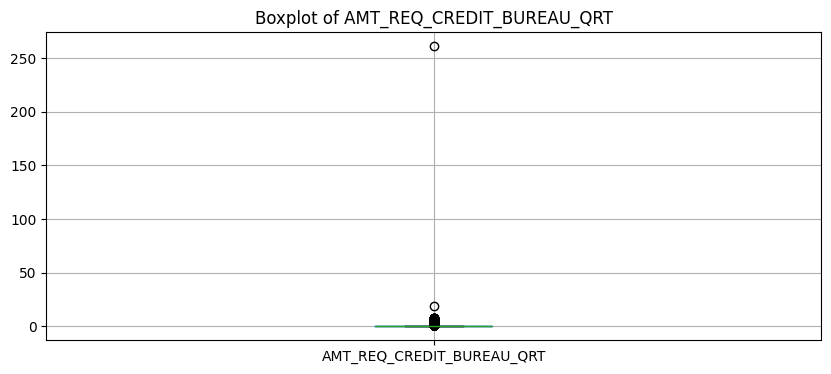

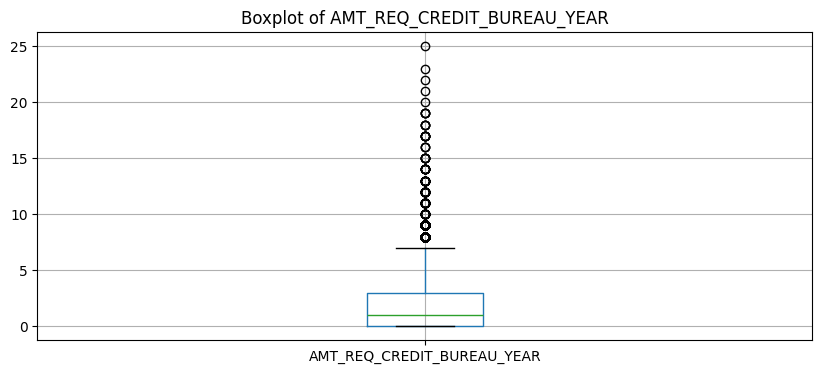

In [9]:
# Plot boxplots for each numeric column
for col in X.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 4))
    X.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()
    
# The output is too long, so just collapse the outputs.

In [10]:
# There are too big or small, I'll eliminate them here.
X = X[X['AMT_INCOME_TOTAL'] <= 1e8]
X = X[X['REGION_POPULATION_RELATIVE'] <= 0.06]
X['DAYS_EMPLOYED'] = X['DAYS_EMPLOYED'].mask(X['DAYS_EMPLOYED'] > 250000, np.nan)
X = X[X['AMT_REQ_CREDIT_BUREAU_QRT'] <= 200]

### Filling missing values

In [11]:
# Drop columns with too many (>90%) missing values.
missing_ratio = X.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.9]\
    .index.tolist()
X.drop(columns=high_missing_cols, inplace=True)

In [12]:
# List missing values.
al.prints(f'dtype(s): {set(X.dtypes)}', s=['g'])
pd.DataFrame([
    {
        'name': col,
        'dtype': X[col].dtype,
        'missing': X[col].isnull().sum()
    }
    for col in X.columns
]).sort_values(by=['dtype', 'missing'], ascending=[True, False])

dtype(s): {dtype('int64'), dtype('float64'), dtype('O')}


,name,dtype,missing
0,SK_ID_CURR,int64,0
5,CNT_CHILDREN,int64,0
16,DAYS_BIRTH,int64,0
19,DAYS_ID_PUBLISH,int64,0
21,FLAG_MOBIL,int64,0
...,...,...,...
12,NAME_EDUCATION_TYPE,object,0
13,NAME_FAMILY_STATUS,object,0
14,NAME_HOUSING_TYPE,object,0
31,WEEKDAY_APPR_PROCESS_START,object,0


In [13]:
for col in X.columns:  # I just learned "inplace: True" is getting deprecated.
    if X[col].dtype == 'object':
        # Fill categorical columns with unknown.
        X[col] = X[col].fillna('Unknown')
    else:
        # Fill numerical columns with median.
        X[col] = X[col].fillna(X[col].median())


In [14]:
# Match the removed columns with y series.
y = y.loc[X.index]

## 8. Feature Engineering

I will include feature engineering step here, as I get better results from scratch.

In [ ]:
# Some steps taken from the leaderboard notebooks.
X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + 1)
X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + 1)
X['CREDIT_ANNUITY_RATIO'] = X['AMT_CREDIT'] / (X['AMT_ANNUITY'] + 1)
X['AGE_YEARS'] = -X['DAYS_BIRTH'] / 365
X['EMPLOYED_YEARS'] = -X['DAYS_EMPLOYED'] / 365

/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/4244387634.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + 1)
/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/4244387634.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + 1)
/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/4244387634.py:4: PerformanceWarning: DataFrame is highly fragment

## 2. Validation Strategy

**I choose: Stratified K-Fold. Why?**

Since this is a task of binary classification, and the target value is imbalanced ($91.93\%$), I prefered Stratified K-Fold. Stratified K-Fold makes sure each fold maintains the same proportion of classes as the overall dataset. This prevents biased training set and provides a more reliable evaluation of model performance.

In [16]:
yc = y.value_counts()
print(yc)
al.prints(f'{yc[0] / (yc[0] + yc[1]) * 100:.2f}% of the data is 0', s=['y'])

TARGET
0    238598
1     20269
Name: count, dtype: int64
92.17% of the data is 0


In [17]:
# Using Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Initial Modelling

In [18]:
X.columns

Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'CREDIT_INCOME_RATIO',
       'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO', 'AGE_YEARS',
       'EMPLOYED_YEARS'],
      dtype='object', length=126)

### 3.1. CatBoost Model

In [19]:
# CatBoost scores.
s_catboost = []

# Categorical columns.
cat_features = X.select_dtypes(include=['object'])\
    .columns.tolist()

if not os.path.exists('s_catboost.txt') or RETRAIN:
    for i, (i_train, i_val) in enumerate(kf.split(X, y)):
        print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
        
        # Split the data into training and validation sets.
        X_train, X_val = X.iloc[i_train], X.iloc[i_val]
        y_train, y_val = y.iloc[i_train], y.iloc[i_val]
        
        # Train the CatBoost model.
        model = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
        model.fit(X_train, y_train, cat_features=cat_features)
        
        # Make predictions and calculate the ROC-AUC score.
        preds = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
        s_catboost.append(score)
        
    # Save the CatBoost scores.
    with open('s_catboost.txt', 'w') as f:
        f.write('\n'.join([str(s) for s in s_catboost]))
else:
    # Load the CatBoost scores.
    with open('s_catboost.txt', 'r') as f:
        s_catboost = [float(s) for s in f.read().splitlines()]

al.prints(f"\nCatBoost average ROC-AUC: {sum(s_catboost) / len(s_catboost):.4f}", s=['g'])

Fold 5 of 5
CatBoost average ROC-AUC: 0.7669


### 3.2. Ridge Model

In [20]:
# Numerical input for Ridge model.
X_encoded = pd.get_dummies(X)

In [21]:
s_ridge = []

with suppress_warnings(categories=(RuntimeWarning,)):
    
    for i, (i_train, i_val) in enumerate(kf.split(X_encoded, y)):
        print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
        
        # Split the data into training and validation sets.
        X_train, X_val = X_encoded.iloc[i_train], X_encoded.iloc[i_val]
        y_train, y_val = y.iloc[i_train], y.iloc[i_val]
        
        # Train the Ridge model.
        model = RidgeClassifier()
        model.fit(X_train, y_train)
        
        # Make predictions and calculate the ROC-AUC score.
        preds = model.decision_function(X_val)
        score = roc_auc_score(y_val, preds)
        s_ridge.append(score)

al.prints(f"\nRidge average ROC-AUC: {sum(s_ridge) / len(s_ridge):.4f}", s=['g'])

Fold 5 of 5
Ridge average ROC-AUC: 0.7506


## 4. Feature Selection with LOFO Importance

Since CatBoost is a robust model, and should use all the features available, LOFO is not needed for it. Therefore, I'm only implementing this for Ridge.

I use X_encoded (numeric features) for LOFO because Ridge needs numeric input.

In [22]:
# Dataset for LOFO.
lofo_dataset = Dataset(
    df=pd.concat([X_encoded, y], axis=1),
    target='TARGET',
    features=X_encoded.columns.tolist()
)

---

It turns out LOFO Importance simply tests the model by removing each feature one-by-one, which takes a lot of time  *(41 minutes)* to compute. This is why I'm directly saving the results.

In [23]:
lofo_imp = LOFOImportance(
    lofo_dataset,
    scoring="roc_auc",
    model=RidgeClassifier(),
    # cv: int, cross-validation generator or an iterable (@sklearn.cross_validate)
    cv=kf  # type: ignore
)

if not os.path.exists('lofo_importance.csv') or RETRAIN:
    importance_df = lofo_imp.get_importance()

    # LOFO Importance took so much time to run, so save the results.
    importance_df.to_csv('lofo_importance.csv', index=False)
else:
    # Load the previous LOFO importance.
    importance_df = pd.read_csv('lofo_importance.csv')

  0%|          | 0/256 [00:00<?, ?it/s]

---

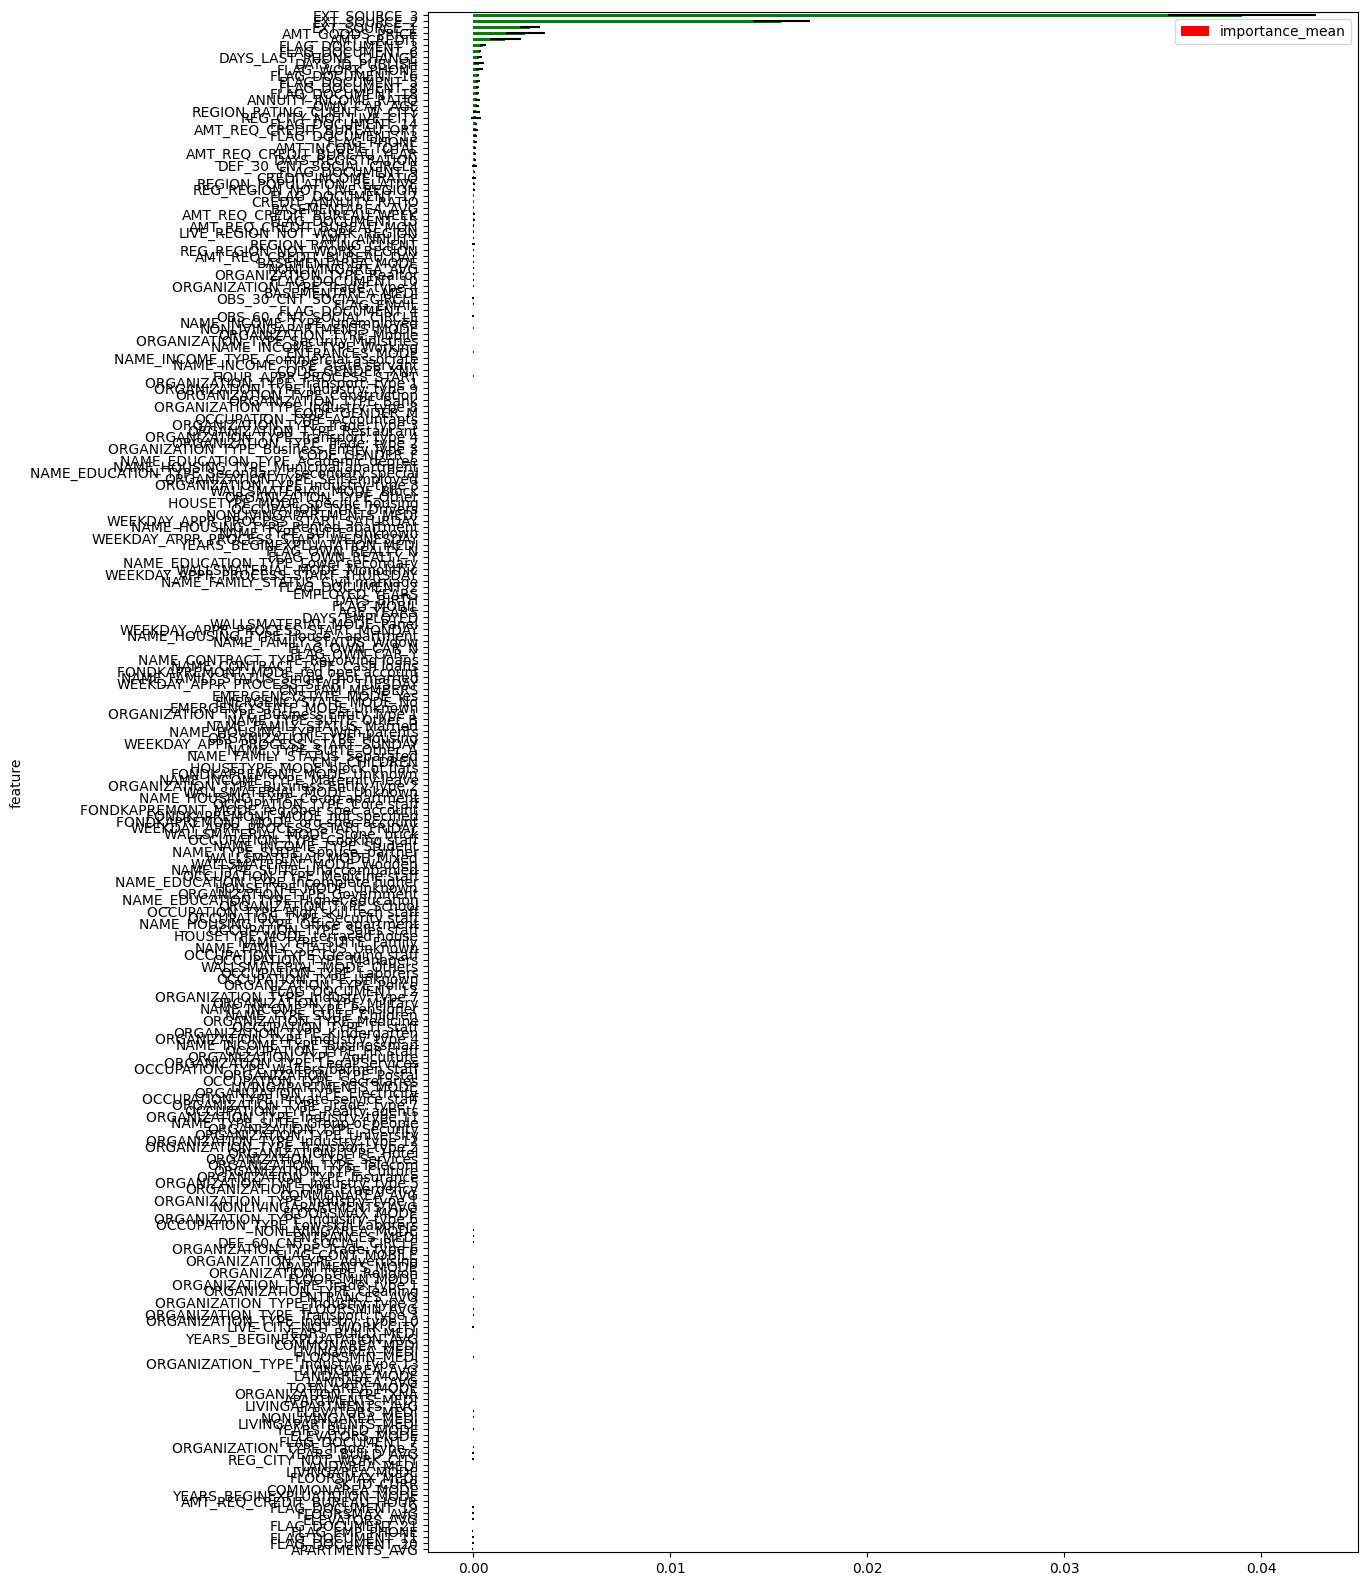

In [24]:
plot_importance(importance_df, figsize=(12, 20))

In [25]:
selected_features = importance_df\
    .sort_values('importance_mean', ascending=False)\
        .head(lofo_dataset.df.shape[1] // 2)['feature']\
            .tolist()

## 5. Hyperparameter Optimisation (Optuna)

### 5.1. CatBoost Model

In [26]:
# Define the objective function for Optuna to optimize CatBoost parameters.
def objective_catboost(trial):
    # Use the selected features from LOFO importance.
    model = CatBoostClassifier(
        depth = trial.suggest_int('depth', 4, 10),
        learning_rate = trial.suggest_float('learning_rate', 1e-3, 1.0),
        l2_leaf_reg = trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
        iterations = 500,
        random_seed = RANDOM_STATE,
        verbose = 0
    )
    
    scores = cross_val_score(
        model,  # type: ignore
        X_encoded[selected_features],
        y,
        cv=kf,
        scoring='roc_auc'
    )
    return scores.mean()

---

CatBoost takes a lot of time by itself, and doing hyperparametre searching using Optuna is lot more. So, save the results again.

In [27]:
# Create an Optuna study for CatBoost.
study_catboost = optuna.create_study(direction='maximize')

if not os.path.exists('catboost_study.pkl') or RETRAIN:
    # Optimize the CatBoost model using Optuna.
    with suppress_warnings(categories=(FutureWarning,)):
        study_catboost.optimize(objective_catboost, n_trials=30)
    
    # Save the study results.
    with open('catboost_study.pkl', 'wb') as f:
        pickle.dump(study_catboost, f)
else:
    # Load the previous Optuna study for CatBoost.
    with open('catboost_study.pkl', 'rb') as f:
        study_catboost = pickle.load(f)

[I 2025-05-03 12:09:21,257] A new study created in memory with name: no-name-715709df-95be-45e7-8bd2-80c65c8e554e
[I 2025-05-03 12:09:45,925] Trial 0 finished with value: 0.7341015049635016 and parameters: {'depth': 4, 'learning_rate': 0.710537319587628, 'l2_leaf_reg': 0.019560778232884282}. Best is trial 0 with value: 0.7341015049635016.
[I 2025-05-03 12:10:16,348] Trial 1 finished with value: 0.6804182141333729 and parameters: {'depth': 6, 'learning_rate': 0.9074711867405655, 'l2_leaf_reg': 1.1481494478474021}. Best is trial 0 with value: 0.7341015049635016.
[I 2025-05-03 12:10:50,684] Trial 2 finished with value: 0.7040638138311996 and parameters: {'depth': 7, 'learning_rate': 0.33494500359909707, 'l2_leaf_reg': 0.005879712095895527}. Best is trial 0 with value: 0.7341015049635016.
[I 2025-05-03 12:11:17,092] Trial 3 finished with value: 0.7196475481386182 and parameters: {'depth': 5, 'learning_rate': 0.6264209196024285, 'l2_leaf_reg': 0.0027441542536984958}. Best is trial 0 with va

---

In [28]:
al.prints(study_catboost.best_params, s=['g'])

{'depth': 6, 'learning_rate': 0.08706260752723924, 'l2_leaf_reg': 0.04424463807825298}


### 5.2. Ridge Model

In [29]:
# Define the objective function for Optuna to optimize Ridge hyperparameters.
def objective_ridge(trial):
    # Use the selected features for the Ridge model.
    model = RidgeClassifier(
        alpha=trial.suggest_loguniform('alpha', 1e-4, 10.0)
    )
    
    # Perform cross-validation.
    scores = cross_val_score(
        model,
        X_encoded[selected_features],
        y,
        cv=kf,
        scoring='roc_auc'
    )
    return scores.mean()

In [30]:
# Create an Optuna study for Ridge.
study_ridge = optuna.create_study(direction='maximize')

# Optimize the Ridge model using Optuna.
with suppress_warnings(categories=(RuntimeWarning, FutureWarning)):
    study_ridge.optimize(objective_ridge, n_trials=30)

[I 2025-05-03 12:32:14,394] A new study created in memory with name: no-name-d4e6c509-f3aa-4144-952d-808cf6677f69
[I 2025-05-03 12:32:15,631] Trial 0 finished with value: 0.7509168730858268 and parameters: {'alpha': 0.23724355969841848}. Best is trial 0 with value: 0.7509168730858268.
[I 2025-05-03 12:32:16,693] Trial 1 finished with value: 0.7509175986740203 and parameters: {'alpha': 0.029773495621718726}. Best is trial 1 with value: 0.7509175986740203.
[I 2025-05-03 12:32:17,659] Trial 2 finished with value: 0.750917565561217 and parameters: {'alpha': 0.0006556839522237261}. Best is trial 1 with value: 0.7509175986740203.
[I 2025-05-03 12:32:18,631] Trial 3 finished with value: 0.750917574868015 and parameters: {'alpha': 0.00023937676879115353}. Best is trial 1 with value: 0.7509175986740203.
[I 2025-05-03 12:32:19,588] Trial 4 finished with value: 0.7509175810697205 and parameters: {'alpha': 0.0024351732103345502}. Best is trial 1 with value: 0.7509175986740203.
[I 2025-05-03 12:32:

In [31]:
al.prints(study_ridge.best_params, s=['g'])

{'alpha': 0.021430819935696056}


## 6. Model Performance Comparison

### 6.1. Model Results

### 6.1.1. Retrain CatBoostClassifier (on all features)

In [32]:
# Align columns to make sure all selected features exist.
missing_cols = [
    col
    for col in selected_features
    if col not in X.columns
]

for col in missing_cols:
    X[col] = 0  # Add missing column filled with zeros.

/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/2503640622.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col] = 0  # Add missing column filled with zeros.
/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/2503640622.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col] = 0  # Add missing column filled with zeros.
/var/folders/1z/s9hv6p7n2b963bjdxrpn2cnh0000gn/T/ipykernel_12043/2503640622.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [34]:
# Get the best parameters for CatBoost from the study.
best_params = study_catboost.best_params
best_params.update({'iterations': 500, 'random_seed': RANDOM_STATE, 'verbose': 0})

sf_catboost = []  # CatBoost final scores.
catboost_model = None  # CatBoost model.

if not os.path.exists('catboost_final_model.pkl') or RETRAIN:
    for i, (train_i, val_i) in enumerate(kf.split(X[selected_features], y)):
        print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
        
        # Split the data into training and validation sets.
        X_train, X_val = X.iloc[train_i][selected_features], X.iloc[val_i][selected_features]
        y_train, y_val = y.iloc[train_i], y.iloc[val_i]

        # Train the CatBoost model with the best parameters.
        catboost_model = CatBoostClassifier(**best_params)
        catboost_model.fit(X_train, y_train)

        # Make predictions and calculate the ROC-AUC score.
        # Note: Using predict_proba instead of predict to get probabilities.
        preds = catboost_model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
        sf_catboost.append(score)
        
    # Save the final CatBoost model.
    with open('catboost_final_model.pkl', 'wb') as f:
        pickle.dump(catboost_model, f)
else:
    # Load the final CatBoost model.
    with open('catboost_final_model.pkl', 'rb') as f:
        catboost_model = pickle.load(f)

print("\n" + al.g("CatBoost Optimised average ROC-AUC: ", False) + al.s(al.g(f"{sum(sf_catboost) / len(sf_catboost):.4f}", False), False))

Fold 5 of 5
CatBoost Optimised average ROC-AUC: 0.7602


### 6.1.2. Retrain RidgeClassifier (on selected features)

In [35]:
# Get the best alpha for Ridge from the study.
best_alpha = study_ridge.best_params['alpha']

fs_ridge = []  # Ridge final scores.
ridge_model = None  # Ridge model.

with suppress_warnings(categories=(RuntimeWarning,)):
    for i, (train_i, val_i) in enumerate(kf.split(X_encoded[selected_features], y)):
        print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
        
        # Split the data into training and validation sets.
        X_train, X_val = X_encoded.iloc[train_i][selected_features], X_encoded.iloc[val_i][selected_features]
        y_train, y_val = y.iloc[train_i], y.iloc[val_i]

        # Train the Ridge model with the best alpha.
        ridge_model = RidgeClassifier(alpha=best_alpha)
        ridge_model.fit(X_train, y_train)

        # Make predictions and calculate the ROC-AUC score.
        # Note: Using decision_function instead of predict to get scores.
        preds = ridge_model.decision_function(X_val)
        score = roc_auc_score(y_val, preds)
        fs_ridge.append(score)

print("\n" + al.g("Ridge Optimised average ROC-AUC: ", False) + al.s(al.g(f"{sum(fs_ridge) / len(fs_ridge):.4f}", False), False))

Fold 5 of 5
Ridge Optimised average ROC-AUC: 0.7509


## 7. Feature Importance using Shap

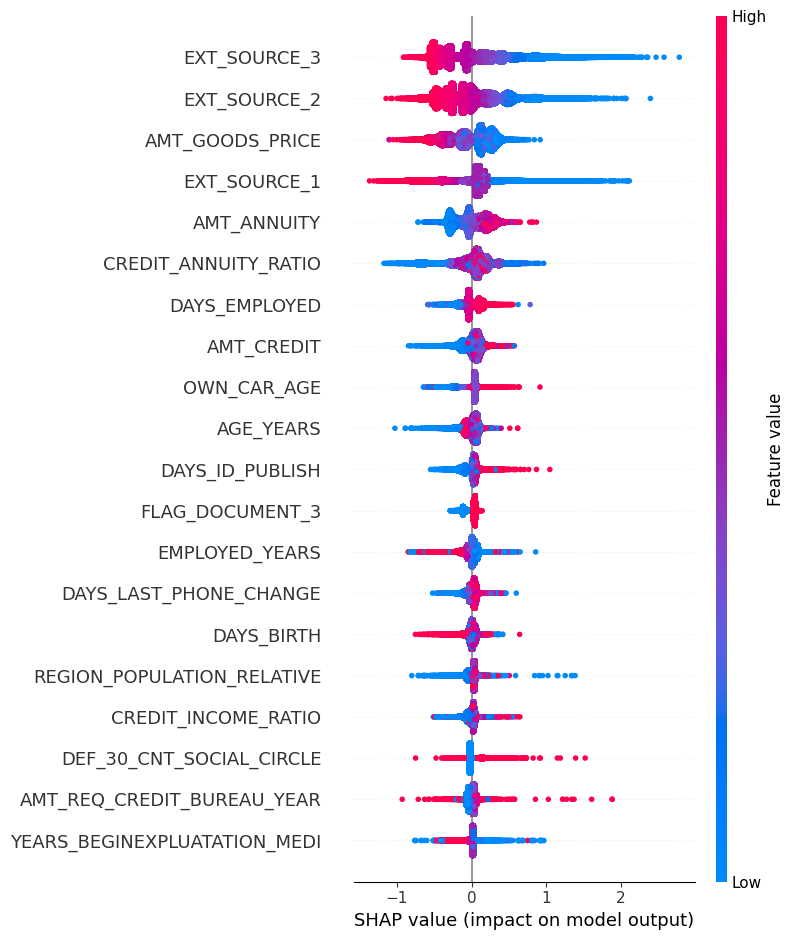

In [36]:
# SHAP explainer for CatBoost.
explainer = shap.TreeExplainer(catboost_model)

# Compute SHAP values.
shap_values = explainer.shap_values(X[selected_features])

# Summary plot.
shap.summary_plot(shap_values, X[selected_features])

In this project, I followed the full machine learning process on the Home Credit Default Risk dataset. I started with cleaning the data (removing outliers and filling missing values), then added some new features, and used LOFO Importance to pick the best features.

I trained both CatBoost and Ridge Classifier models, tested them, and tuned their parameters using Optuna. Even after tuning and adding new features, the model results didn’t improve much. The ROC-AUC stayed around ```0.76``` for CatBoost and ```0.75``` for Ridge. I think this is because:

* The dataset is difficult, and many features are not very useful.
* CatBoost already handles feature interactions well, so extra features didn’t help much.
* Maybe more domain knowledge is needed to create better features.

I also used SHAP to explain the CatBoost model. The results showed that only a few features really affected the prediction, and these made sense for the problem.

In the end, even though the scores didn’t improve a lot, I completed all steps of a machine learning pipeline: cleaning data, validating models, selecting features, tuning parameters, explaining results, and adding new features. I learned a lot about the process. And also considering the leaderboard for the Kaggle Challange itself, the best score being ```0.80``` gave me the confidence that my results are enough for this task.